# Rare-class quota: does it improve the classes it targets? (axis-200-900)

The rare quota adds 30 synthetic tokens for every class of the least-annotated quarter of the generator-eligible classes. If the mechanism works, exactly those classes should gain, and they should gain more than the other eligible classes and more than in the matched variant without the quota.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Matched controls.** P4 joint vs P2 joint, P4 staged vs P2 staged, P5 joint vs P3 joint and P5 staged vs P3
  staged differ only in the rare quota; paired by stage and repetition.
* **Class sets.** `rare`: generator-eligible classes that received rare-bonus tokens; `other_eligible`: the
  remaining generator-eligible classes. Classes the generator cannot synthesize are excluded from both.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

* $n_c$: training annotation count of class $c$; eligible classes are ranked by $n_c$ (ties by class index) and the
  lowest $\lceil 0.25 \cdot |\mathrm{eligible}| \rceil$ are rare.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "rare_classes"
AXIS = "axis-200-900"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

classes = table('classes')
baseline_summary = table('baseline_summary')
control_summary = table('control_summary')
PAIRS = settings['targeted']['rare']['pairs']
TREATED = list(PAIRS)
PAIR_LABELS = {treated: f"{VARIANT_LABELS[treated]} - {VARIANT_LABELS[control]}" for treated, control in PAIRS.items()}
print('Rare classes:', metadata['rare_classes'], '| eligible:', metadata['eligible_classes'], '| cutoff rank:', metadata['cutoff_rank'])

Analysis: rare_classes | axis: axis-200-900 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Rare classes: 25 | eligible: 97 | cutoff rank: 25.0


## Producing the tables this notebook reads

### Methodology

#### Implementation

`rare_classes` reads the class flags of the regenerated synthetic artifact (`synthetic_reference` level: the
rare set is read from the rare-bonus tokens of the manifest and checked against the configured rule), the
per-class head tables of every model and the stored logits for the true-label ranks.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis rare_classes > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute metrics of the targeted class sets against the real-only baseline

### Methodology

#### Theoretical

The improvements and matched controls below are differences; this section shows the level of every
targeted class-set metric for the real-only baseline and every variant at every stage.

#### Implementation

`set_metrics` holds one value per model, class set, metric and evaluation population.

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

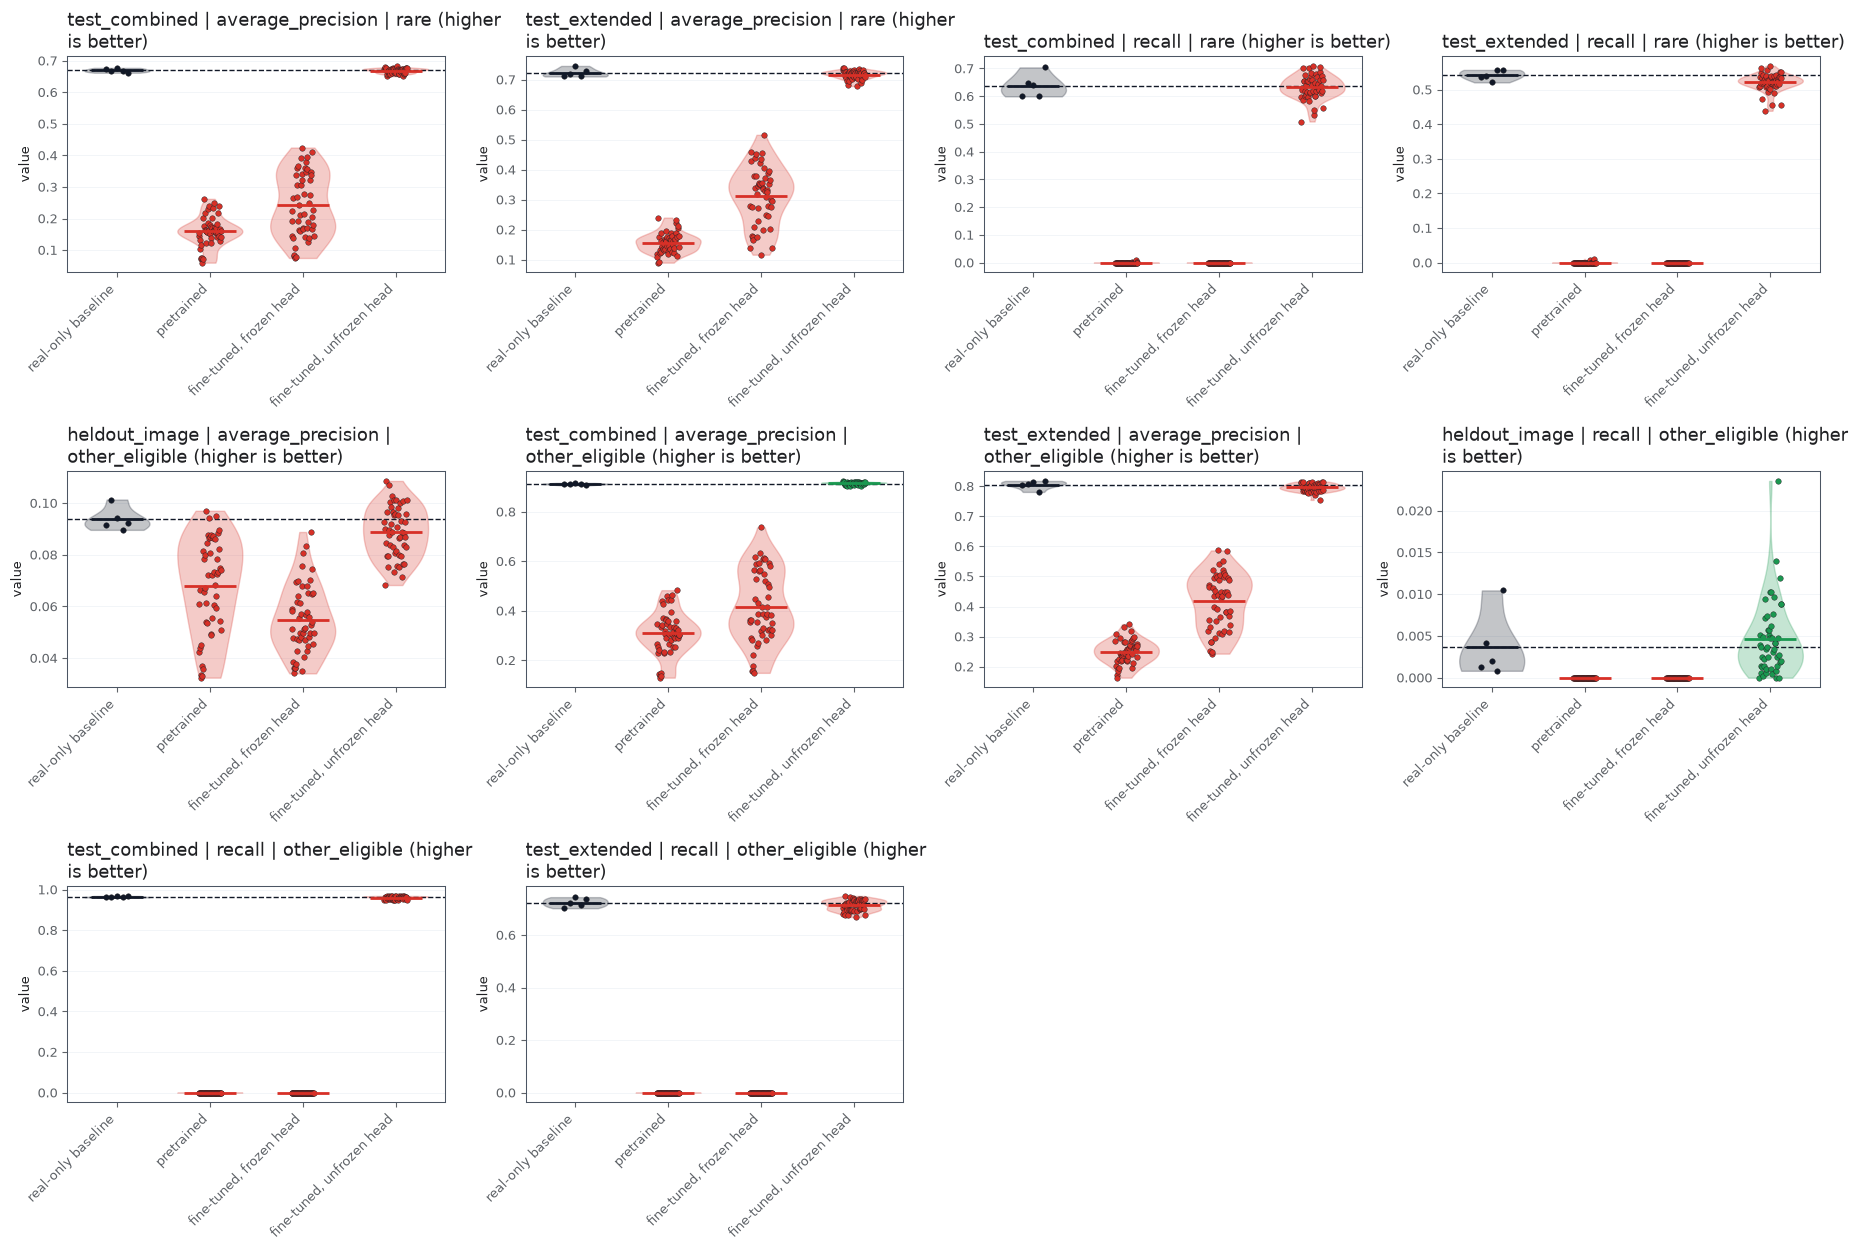

test_combined | average_precision | rare


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.670 +/- 0.006,0.670 +/- 0.006,0.670 +/- 0.006
P0_single,0.130 +/- 0.021,0.193 +/- 0.053,0.676 +/- 0.002
P1_permutation,0.070 +/- 0.006,0.085 +/- 0.012,0.661 +/- 0.006
P2_joint_base,0.205 +/- 0.039,0.328 +/- 0.041,0.665 +/- 0.004
P2_staged_base,0.151 +/- 0.017,0.195 +/- 0.034,0.671 +/- 0.007
P3_joint_overlap,0.200 +/- 0.033,0.357 +/- 0.050,0.668 +/- 0.005
P3_staged_overlap,0.152 +/- 0.021,0.194 +/- 0.054,0.673 +/- 0.008
P4_joint_rare,0.202 +/- 0.040,0.368 +/- 0.019,0.666 +/- 0.007
P4_staged_rare,0.164 +/- 0.007,0.175 +/- 0.049,0.668 +/- 0.004


test_extended | average_precision | rare


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.723 +/- 0.015,0.723 +/- 0.015,0.723 +/- 0.015
P0_single,0.147 +/- 0.061,0.316 +/- 0.131,0.734 +/- 0.005
P1_permutation,0.127 +/- 0.025,0.180 +/- 0.018,0.712 +/- 0.013
P2_joint_base,0.155 +/- 0.022,0.397 +/- 0.047,0.707 +/- 0.018
P2_staged_base,0.151 +/- 0.017,0.268 +/- 0.068,0.719 +/- 0.008
P3_joint_overlap,0.161 +/- 0.027,0.384 +/- 0.041,0.716 +/- 0.011
P3_staged_overlap,0.149 +/- 0.022,0.321 +/- 0.124,0.722 +/- 0.008
P4_joint_rare,0.164 +/- 0.025,0.364 +/- 0.116,0.708 +/- 0.019
P4_staged_rare,0.147 +/- 0.018,0.292 +/- 0.043,0.724 +/- 0.007


test_combined | recall | rare


...

stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.004 +/- 0.004,0.004 +/- 0.004,0.004 +/- 0.004
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.002 +/- 0.002
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.002 +/- 0.002
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.005 +/- 0.003
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.003 +/- 0.003
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.002
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.005 +/- 0.004
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.003
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.004 +/- 0.006


test_combined | recall | other_eligible


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.965 +/- 0.003,0.965 +/- 0.003,0.965 +/- 0.003
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.956 +/- 0.009
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.964 +/- 0.003
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.960 +/- 0.005
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.958 +/- 0.009
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.958 +/- 0.009
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.957 +/- 0.009
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.962 +/- 0.004
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.964 +/- 0.002


test_extended | recall | other_eligible


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.724 +/- 0.017,0.724 +/- 0.017,0.724 +/- 0.017
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.700 +/- 0.015
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.714 +/- 0.026
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.702 +/- 0.019
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.710 +/- 0.023
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.717 +/- 0.022
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.714 +/- 0.027
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.722 +/- 0.018
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.712 +/- 0.016


In [4]:
frame_abs = table('set_metrics')

SELECTORS_ABS = [["test_combined | average_precision | rare", {"evaluation": "test_combined", "metric": "average_precision", "class_set": "rare"}, "higher"], ["test_extended | average_precision | rare", {"evaluation": "test_extended", "metric": "average_precision", "class_set": "rare"}, "higher"], ["test_combined | recall | rare", {"evaluation": "test_combined", "metric": "recall", "class_set": "rare"}, "higher"], ["test_extended | recall | rare", {"evaluation": "test_extended", "metric": "recall", "class_set": "rare"}, "higher"], ["heldout_image | average_precision | other_eligible", {"evaluation": "heldout_image", "metric": "average_precision", "class_set": "other_eligible"}, "higher"], ["test_combined | average_precision | other_eligible", {"evaluation": "test_combined", "metric": "average_precision", "class_set": "other_eligible"}, "higher"], ["test_extended | average_precision | other_eligible", {"evaluation": "test_extended", "metric": "average_precision", "class_set": "other_eligible"}, "higher"], ["heldout_image | recall | other_eligible", {"evaluation": "heldout_image", "metric": "recall", "class_set": "other_eligible"}, "higher"], ["test_combined | recall | other_eligible", {"evaluation": "test_combined", "metric": "recall", "class_set": "other_eligible"}, "higher"], ["test_extended | recall | other_eligible", {"evaluation": "test_extended", "metric": "recall", "class_set": "other_eligible"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

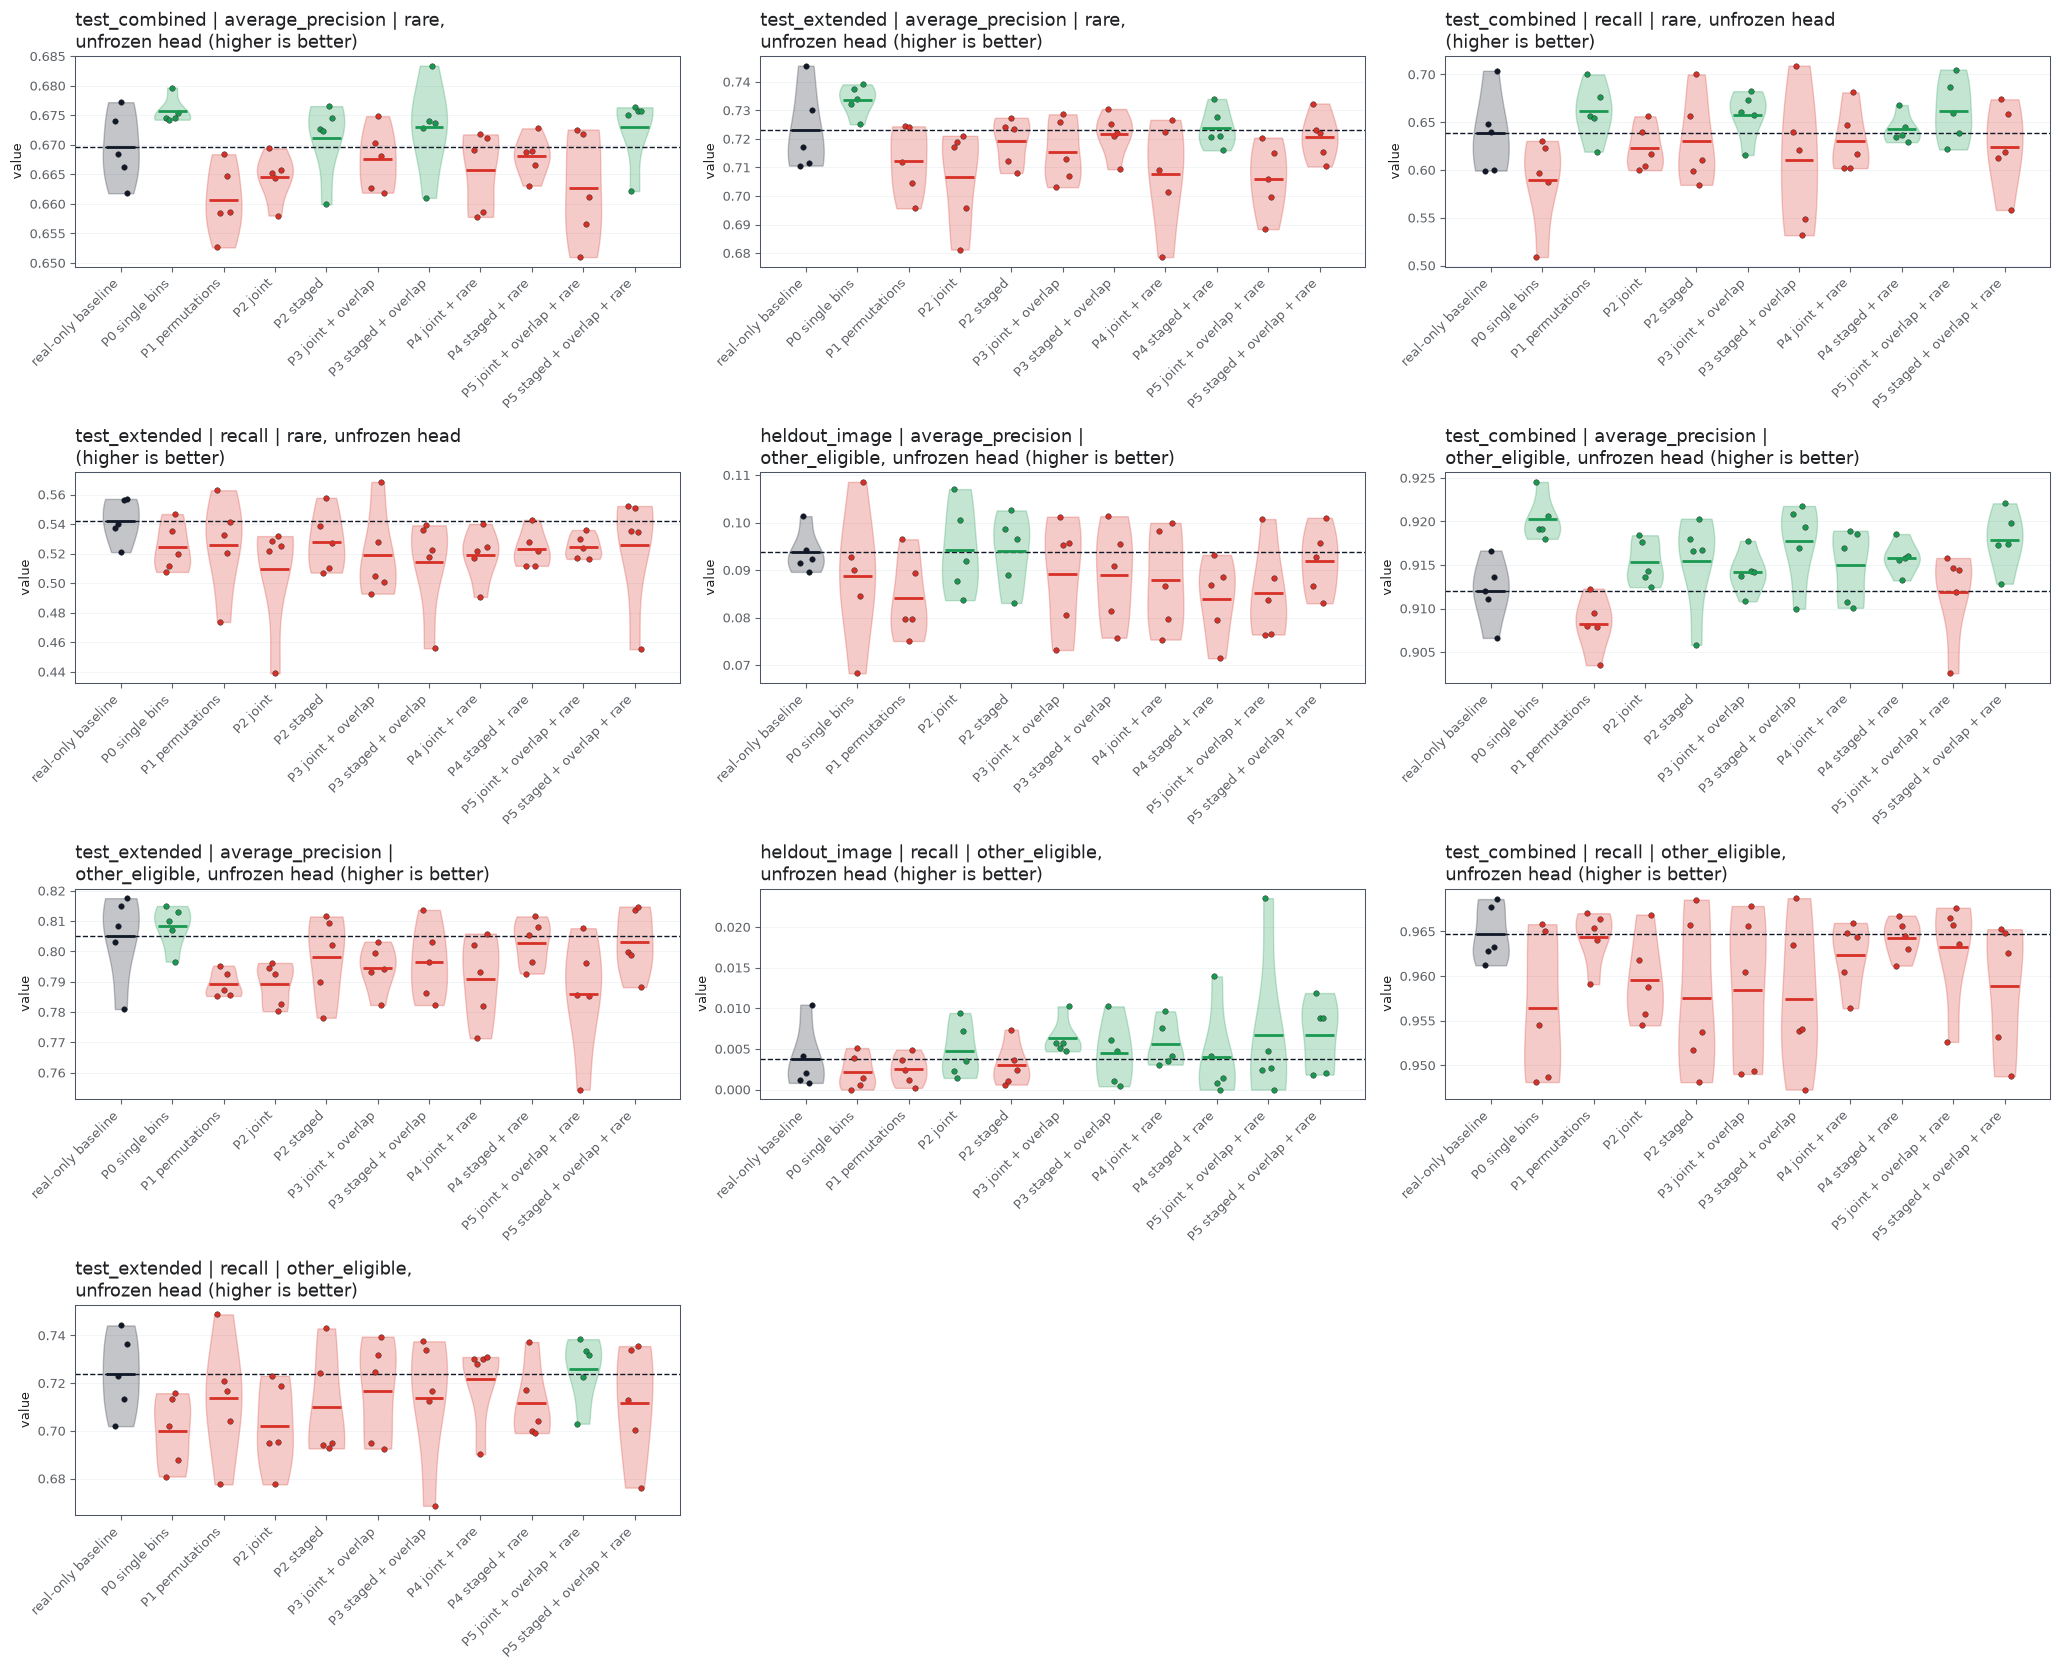

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- test_combined | average_precision | rare (by stage, variants pooled): baseline 0.6696; others 0.161-0.6682; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6682), worst pretrained (0.161).
- test_combined | average_precision | rare (unfrozen head, per variant): baseline 0.6696; others 0.6606-0.6757; 4 of 10 better than the baseline; best P0 single bins (0.6757), worst P1 permutations (0.6606).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.6757 vs baseline 0.6696).
- test_extended | average_precision | rare (by stage, variants pooled): baseline 0.7231; others 0.1568-0.7167; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7167), worst pretrained (0.1568).
- test_extended | average_precision | rare (unfrozen head, per variant): baseline 0.7231; others 0.7059-0.7336; 2 of 10 better than the baseline; best P0 single bins (0.7336), worst P5 joint + overlap + rare (0.7059).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.7336 vs baseline 0.7231).
- test_combined | recall | rare (by stage, variants pooled): baseline 0.6383; others 1.563e-06-0.6331; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6331), worst fine-tuned, frozen head (1.563e-06).
- test_combined | recall | rare (unfrozen head, per variant): baseline 0.6383; others 0.5892-0.6622; 4 of 10 better than the baseline; best P5 joint + overlap + rare (0.6622), worst P0 single bins (0.5892).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.6622 vs baseline 0.6383).
- test_extended | recall | rare (by stage, variants pooled): baseline 0.5425; others 0-0.5214; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5214), worst fine-tuned, frozen head (0).
- test_extended | recall | rare (unfrozen head, per variant): baseline 0.5425; others 0.5094-0.5282; 0 of 10 better than the baseline; best P2 staged (0.5282), worst P2 joint (0.5094).
  best single cell: P2 staged, fine-tuned, unfrozen head (0.5282 vs baseline 0.5425).
- heldout_image | average_precision | other_eligible (by stage, variants pooled): baseline 0.09385; others 0.05492-0.08881; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.08881), worst fine-tuned, frozen head (0.05492).
- heldout_image | average_precision | other_eligible (unfrozen head, per variant): baseline 0.09385; others 0.08393-0.09421; 2 of 10 better than the baseline; best P2 joint (0.09421), worst P4 staged + rare (0.08393).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.09421 vs baseline 0.09385).
- test_combined | average_precision | other_eligible (by stage, variants pooled): baseline 0.912; others 0.3087-0.9152; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9152), worst pretrained (0.3087).
- test_combined | average_precision | other_eligible (unfrozen head, per variant): baseline 0.912; others 0.9082-0.9203; 8 of 10 better than the baseline; best P0 single bins (0.9203), worst P1 permutations (0.9082).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.9203 vs baseline 0.912).
- test_extended | average_precision | other_eligible (by stage, variants pooled): baseline 0.805; others 0.2504-0.7959; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7959), worst pretrained (0.2504).
- test_extended | average_precision | other_eligible (unfrozen head, per variant): baseline 0.805; others 0.7858-0.8084; 1 of 10 better than the baseline; best P0 single bins (0.8084), worst P5 joint + overlap + rare (0.7858).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8084 vs baseline 0.805).
- heldout_image | recall | other_eligible (by stage, variants pooled): baseline 0.003728; others 0-0.004629; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.004629), worst fine-tuned, frozen head (0).
- heldout_image | recall | other_eligible (unfrozen head, per variant): baseline 0.003728; others 0.002212-0.006678; 7 of 10 better than the baseline; best P5 joint + overlap + rare (0.006678), worst P0 single bins (0.002212).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.006678 vs baseline 0.003728).
- test_combined | recall | other_eligible (by stage, variants pooled): baseline 0.9648; others 0-0.9603; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9603), worst fine-tuned, frozen head (0).
- test_combined | recall | other_eligible (unfrozen head, per variant): baseline 0.9648; others 0.9564-0.9644; 0 of 10 better than the baseline; best P1 permutations (0.9644), worst P0 single bins (0.9564).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9644 vs baseline 0.9648).
- test_extended | recall | other_eligible (by stage, variants pooled): baseline 0.7238; others 0-0.7127; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7127), worst fine-tuned, frozen head (0).
- test_extended | recall | other_eligible (unfrozen head, per variant): baseline 0.7238; others 0.6999-0.7259; 1 of 10 better than the baseline; best P5 joint + overlap + rare (0.7259), worst P0 single bins (0.6999).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.7259 vs baseline 0.7238).

### Notes

## Targeted classes and their synthetic exposure

### Methodology

#### Theoretical

Which classes the quota targets and how much synthetic exposure they receive. A rare class is rare in the
real training data; its test support comes mostly from the test extension.

#### Implementation

`classes` (flags, annotation counts, ranks) and `exposure` (tokens of the rare classes per population and kind).

#### Figure descriptions

No figure; counts and ranges of the class sets, then the tokens per population and kind.

In [6]:
classes['set'] = np.where(~classes.generator_eligible.astype(bool), 'not eligible', np.where(classes.rare.astype(bool), 'rare', 'other_eligible'))
display(classes.groupby('set').agg(classes=('class_index', 'size'), min_train_positives=('train_positives', 'min'),
                                   median_train_positives=('train_positives', 'median'), max_train_positives=('train_positives', 'max')))
display(table('exposure').pivot_table(index='population', columns='kind', values='tokens', aggfunc='sum', fill_value=0))

,classes,min_train_positives,median_train_positives,max_train_positives
set,,,,
not eligible,411,1,865.0,19293
other_eligible,72,10256,14330.5,24409
rare,25,726,7699.0,13344


kind,base_class,overlap_bonus,rare_bonus,single
population,,,,
axis,0,0,0,250
joint_all,750,180,750,250
joint_base,750,0,0,250
joint_overlap,750,180,0,250
joint_rare,750,0,750,250
permutation_all,750,180,750,0
permutation_base,750,0,0,0
permutation_overlap,750,180,0,0
permutation_rare,750,0,750,0


### Remarks

- 97 of 508 head classes are generator-eligible; 25 are rare. Rare classes have 726-13344 training positives (median 7699): they are the least-annotated eligible classes, not rare classes of the head (the head's rarest classes, down to 1 training positive, are not generator-eligible).

### Notes

## Rare and other eligible classes against the baseline

### Methodology

#### Theoretical

Macro AP over each class set (eligible classes of the evaluation), paired against the baseline. The quota
works if the rare-set improvement of P4/P5 exceeds that of P2/P3 and that of the other eligible classes.

#### Implementation

`baseline_improvements` (per model) and `baseline_summary`.

#### Figure descriptions

Forest plot: rows = variants, panels = stage x class set (test + extension).

evaluation                              heldout_image                                                                                               test_combined                                   \
class_set                              other_eligible                                                                                              other_eligible                                    
stage                                     frozen_head                           pretrained                         unfrozen_head                      frozen_head                       pretrained   
variant                                                                                                                                                                                              
P0_single           -0.043 [-0.0513, -0.0346] (+0/-5)   -0.0422 [-0.0606, -0.0238] (+0/-5)    -0.00505 [-0.0243, 0.0142] (+2/-3)  -0.582 [-0.632, -0.532] (+0/-5)  -0.645 [-0.703, -0.587] (+0/-5)   
P1_permutation     -0.0578 [-0.0647, -0.0508] (+0/-5)    -0.0595 [-0.0661, -0.053] (+0/-5)   -0.00977 [-0.0236, 0.00401] (+1/-4)   -0.74 [-0.775, -0.705] (+0/-5)  -0.773 [-0.783, -0.763] (+0/-5)   
P2_joint_base      -0.0356 [-0.0547, -0.0166] (+0/-5)  -0.0193 [-0.0302, -0.00841] (+0/-5)    0.000362 [-0.0135, 0.0142] (+2/-3)  -0.364 [-0.441, -0.286] (+0/-5)     -0.53 [-0.59, -0.47] (+0/-5)   
P2_staged_base     -0.0383 [-0.0522, -0.0245] (+0/-5)    -0.0238 [-0.0519, 0.0044] (+1/-4)    0.000113 [-0.0112, 0.0114] (+3/-2)   -0.572 [-0.66, -0.483] (+0/-5)  -0.637 [-0.688, -0.586] (+0/-5)   
P3_joint_overlap   -0.0371 [-0.0592, -0.0151] (+0/-5)  -0.00835 [-0.0229, 0.00621] (+0/-5)   -0.00464 [-0.0159, 0.00657] (+2/-3)  -0.294 [-0.386, -0.201] (+0/-5)  -0.516 [-0.581, -0.451] (+0/-5)   
P3_staged_overlap    -0.04 [-0.0615, -0.0185] (+0/-5)   -0.0261 [-0.053, 0.000893] (+0/-5)    -0.00489 [-0.0199, 0.0102] (+2/-3)  -0.561 [-0.618, -0.503] (+0/-5)  -0.612 [-0.677, -0.547] (+0/-5)   
P4_joint_rare      -0.0353 [-0.0542, -0.0165] (+0/-5)  -0.0213 [-0.0364, -0.00615] (+0/-5)     -0.00587 [-0.023, 0.0112] (+2/-3)  -0.333 [-0.387, -0.279] (+0/-5)  -0.535 [-0.635, -0.434] (+0/-5)   
P4_staged_rare     -0.0375 [-0.0492, -0.0258] (+0/-5)   -0.0192 [-0.0415, 0.00306] (+1/-4)  -0.00992 [-0.0178, -0.00209] (+0/-5)  -0.556 [-0.619, -0.493] (+0/-5)   -0.622 [-0.665, -0.58] (+0/-5)   
P5_joint_all       -0.0267 [-0.049, -0.00438] (+0/-5)  -0.0149 [-0.0258, -0.00396] (+0/-5)   -0.00869 [-0.0242, 0.00683] (+1/-4)  -0.386 [-0.458, -0.314] (+0/-5)   -0.556 [-0.653, -0.46] (+0/-5)   
P5_staged_all       -0.038 [-0.0522, -0.0237] (+0/-5)  -0.0252 [-0.0486, -0.00179] (+0/-5)   -0.00201 [-0.0108, 0.00676] (+2/-3)   -0.576 [-0.611, -0.54] (+0/-5)   -0.607 [-0.62, -0.595] (+0/-5)   

evaluation                                                                                                                                                                         test_extended  \
class_set                                                                           rare                                                                                          other_eligible   
stage                                     unfrozen_head                      frozen_head                       pretrained                         unfrozen_head                      frozen_head   
variant                                                                                                                                                                                            
P0_single             0.00828 [0.00211, 0.0144] (+5/-0)  -0.477 [-0.542, -0.412] (+0/-5)  -0.539 [-0.563, -0.516] (+0/-5)   0.00615 [-0.000259, 0.0126] (+5/-0)  -0.417 [-0.517, -0.317] (+0/-5)   
P1_permutation     -0.00378 [-0.0077, 0.000138] (+1/-4)  -0.585 [-0.604, -0.565] (+0/-5)  -0.599 [-0.613, -0.586] (+0/-5)  -0.00898 [-0.0187, 0.000733] (+0/-5)  -0.543 [-0.563, -0.523] (+0/-5)   
P2_joint_base          0.0033 [-0.002, 0.00859] (+4

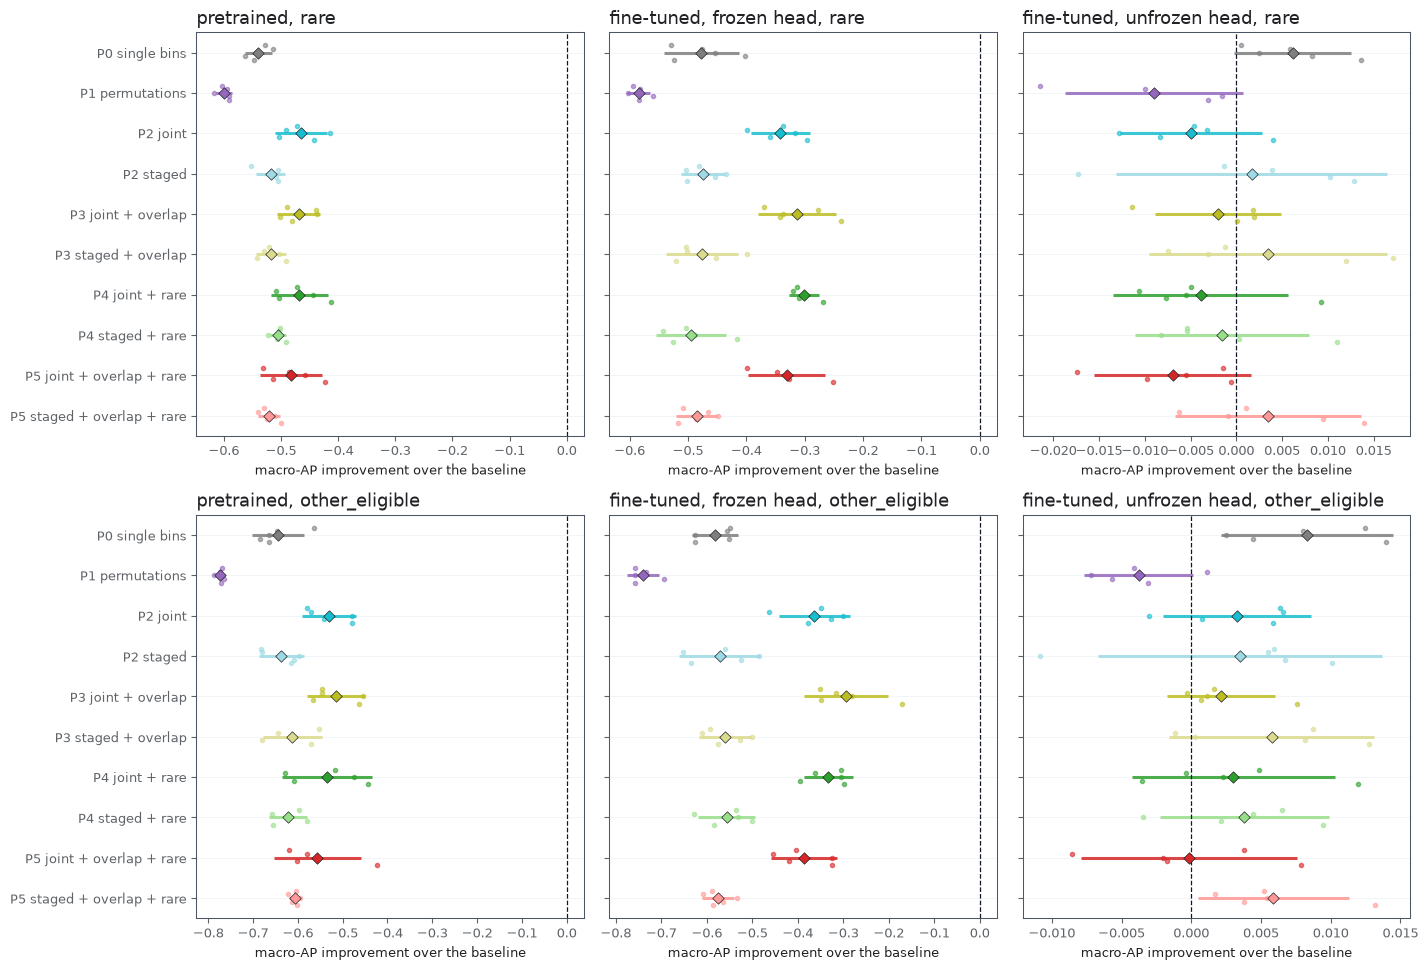

In [7]:
rows = baseline_summary[(baseline_summary.metric == 'average_precision') & (baseline_summary.evaluation == 'test_combined')]
panels = [(f"{STAGE_LABELS[stage]}, {class_set}", {'stage': stage, 'class_set': class_set}) for class_set in ['rare', 'other_eligible'] for stage in STAGES]
paired = table('baseline_improvements')
figures.improvement_forest(rows, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=paired[(paired.metric == 'average_precision') & (paired.evaluation == 'test_combined')], columns=3,
                           xlabel='macro-AP improvement over the baseline', theme=theme);
shown = baseline_summary[baseline_summary.metric == 'average_precision']
display(shown.assign(result=interval(shown)).pivot_table(index='variant', columns=['evaluation', 'class_set', 'stage'], values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- frozen head, other_eligible: macro-AP improvement -0.74 to -0.294; above zero: none; below: 10 variants.
- frozen head, rare: macro-AP improvement -0.585 to -0.302; above zero: none; below: 10 variants.
- pretrained, other_eligible: macro-AP improvement -0.773 to -0.516; above zero: none; below: 10 variants.
- pretrained, rare: macro-AP improvement -0.599 to -0.465; above zero: none; below: 10 variants.
- unfrozen head, other_eligible: macro-AP improvement -0.00378 to 0.00828; above zero: P0 single bins, P5 staged + overlap + rare; below: 0 variants.
- unfrozen head, rare: macro-AP improvement -0.00898 to 0.00615; above zero: none; below: 0 variants.

### Notes

## Rare quota against the matched control

### Methodology

#### Theoretical

The direct test of the mechanism: variant with the quota minus the same variant without it, paired by stage
and repetition. A positive rare-set effect with no other-eligible effect is the signature of a working
quota.

#### Implementation

`control_improvements` and `control_summary`.

#### Figure descriptions

Forest plot: rows = treated variants (label: treated - control), panels = stage x class set (test + extension).

evaluation                           heldout_image                                                                                                 test_combined                                     \
class_set                           other_eligible                                                                                                other_eligible                                      
stage                                  frozen_head                            pretrained                        unfrozen_head                        frozen_head                         pretrained   
variant                                                                                                                                                                                               
P4_joint_rare    0.000319 [-0.0263, 0.027] (+3/-2)     -0.00198 [-0.024, 0.0201] (+2/-3)  -0.00623 [-0.0172, 0.00475] (+1/-4)    0.0308 [-0.0532, 0.115] (+3/-2)  -0.0047 [-0.0751, 0.0657] (+3/-2)   
P4_staged_rare  0.000811 [-0.0152, 0.0168] (+3/-2)    0.00455 [-0.00753, 0.0166] (+4/-1)     -0.01 [-0.0222, 0.00214] (+1/-4)    0.0154 [-0.029, 0.0599] (+4/-1)   0.0143 [-0.0478, 0.0764] (+3/-2)   
P5_joint_all      0.0105 [-0.0144, 0.0353] (+4/-1)  -0.00653 [-0.0128, -0.00025] (+1/-4)     -0.00405 [-0.0281, 0.02] (+1/-4)  -0.0924 [-0.155, -0.0295] (+0/-5)   -0.0407 [-0.107, 0.0254] (+1/-4)   
P5_staged_all    0.00199 [-0.0116, 0.0156] (+4/-1)    0.000892 [-0.0225, 0.0243] (+3/-2)   0.00288 [-0.00968, 0.0154] (+4/-1)   -0.015 [-0.0393, 0.0092] (+2/-3)  0.00466 [-0.0546, 0.0639] (+3/-2)   

evaluation                                                                                                                                                                            test_extended  \
class_set                                                                           rare                                                                                             other_eligible   
stage                                  unfrozen_head                         frozen_head                          pretrained                        unfrozen_head                       frozen_head   
variant                                                                                                                                                                                               
P4_joint_rare   -0.000272 [-0.00745, 0.0069] (+2/-3)     0.0396 [0.0081, 0.0712] (+5/-0)  -0.00299 [-0.0304, 0.0244] (+3/-2)   0.0011 [-0.00602, 0.00823] (+3/-2)  0.000278 [-0.165, 0.165] (+3/-2)   
P4_staged_rare   0.000346 [-0.0051, 0.00579] (+2/-3)     -0.02 [-0.0633, 0.0232] (+1/-4)    0.0126 [-0.0155, 0.0408] (+4/-1)   -0.00321 [-0.0127, 0.0063] (+1/-4)   0.0341 [-0.0208, 0.089] (+4/-1)   
P5_joint_all    -0.00229 [-0.00719, 0.00262] (+2/-3)    -0.018 [-0.0601, 0.0241] (+2/-3)   -0.0135 [-0.0664, 0.0394] (+1/-4)  -0.00492 [-0.0187, 0.00886] (+1/-4)  -0.0405 [-0.103, 0.0216] (+1/-4)   
P5_staged_all   0.000109 [-0.00497, 0.00519] (+3/-2)  -0.00945 [-0.0513, 0.0324] (+2/-3)    -0.0034 [-0.019, 0.0122] (+1/-4)  7.46e-06 [-0.0053, 0.00532] (+4/-1)  -0.0329 [-0.107, 0.0414] (+1/-4)   

evaluation                                                                                                                                                                                           
class_set                                                                                                            rare                                                                            
stage                                    pretrained                       unfrozen_head                       frozen_head                         pretrained                          unfrozen_head  
variant                                                                                                                                                                                              
P4_joint_rare       0.

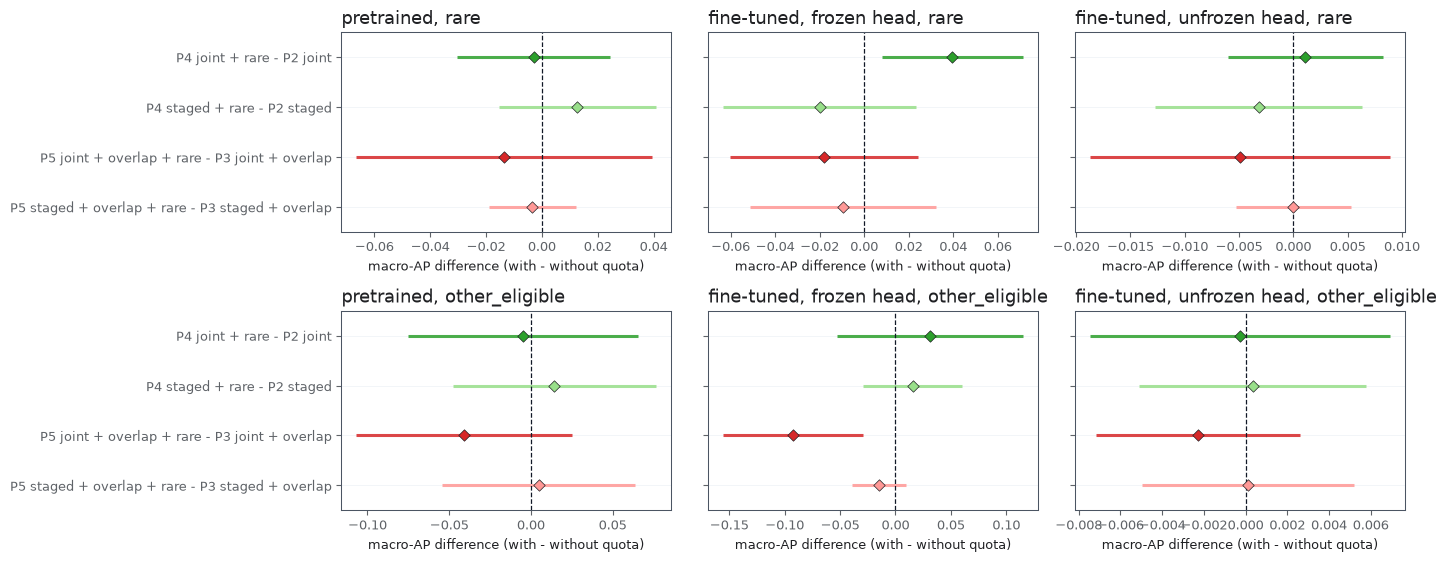

In [8]:
rows = control_summary[(control_summary.metric == 'average_precision') & (control_summary.evaluation == 'test_combined')]
figures.improvement_forest(rows, panels=panels, variants=TREATED, labels=PAIR_LABELS, colors=VARIANT_COLORS, columns=3,
                           xlabel='macro-AP difference (with - without quota)', theme=theme);
shown = control_summary[control_summary.metric == 'average_precision']
display(shown.assign(result=interval(shown)).pivot_table(index='variant', columns=['evaluation', 'class_set', 'stage'], values='result', aggfunc='first').reindex(TREATED))

### Remarks

- held-out, pretrained, other_eligible: with quota better for none; worse for P5 joint + overlap + rare.
- test+ext, frozen head, other_eligible: with quota better for none; worse for P5 joint + overlap + rare.
- test+ext, frozen head, rare: with quota better for P4 joint + rare; worse for none.
- test_extended, pretrained, other_eligible: with quota better for P4 joint + rare; worse for none.
- All other treated x stage x class-set x evaluation cells are inconclusive.

### Notes

## Dose response: class improvement against annotation count

### Methodology

#### Theoretical

Per class, the mean AP improvement over the baseline against its training annotation count. If the quota
acts, rare classes (left of the cutoff) should lie above the other eligible classes for P4/P5 but not for
P2/P3.

#### Implementation

`dose_response` (per class and cell; eligible classes of the evaluation).

#### Figure descriptions

Panels = P2-P5 joint variants at the unfrozen stage (test + extension); x = annotation count (log), y = mean AP improvement, colour = class set.

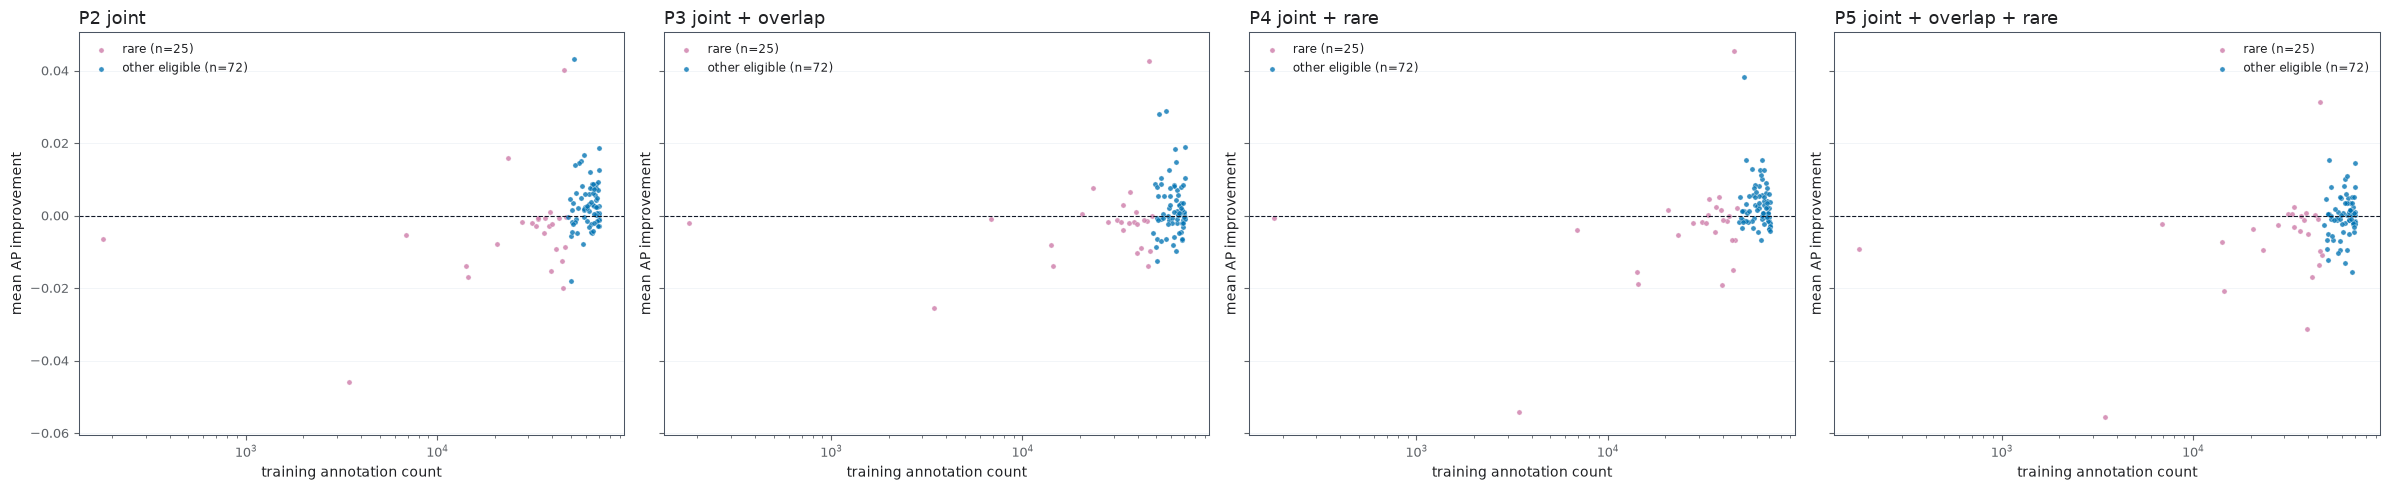

In [9]:
dose = table('dose_response')
dose = dose[(dose.evaluation == 'test_combined') & dose.generator_eligible.astype(bool) & (dose.stage == 'unfrozen_head')].copy()
dose['set'] = np.where(dose.rare.astype(bool), 'rare', 'other eligible')
shown = ['P2_joint_base', 'P3_joint_overlap', 'P4_joint_rare', 'P5_joint_all']
figure, axes = plt.subplots(1, 4, figsize=(24, 5), dpi=theme.figure_dpi, sharey=True)
for ax, variant in zip(axes, shown):
    figures.paired_scatter(dose[dose.variant == variant], x='annotation_count', y='mean', hue='set', hue_order=['rare', 'other eligible'],
                           colors={'rare': theme.model_palette[3], 'other eligible': theme.model_palette[0]}, xlabel='training annotation count',
                           ylabel='mean AP improvement', title=VARIANT_LABELS[variant], diagonal=False, ax=ax, theme=theme)
    ax.set_xscale('log')
    ax.axhline(0.0, color=theme.baseline_color, linestyle='--', linewidth=0.8)
figure.tight_layout()

### Remarks

- At the unfrozen stage the class improvements scatter around zero for rare and other eligible classes alike, with no separation for P4 / P5 relative to P2 / P3.

### Notes

## Classes just below and just above the rare cutoff

### Methodology

#### Theoretical

Classes ranked just below the cutoff (rare, bonus tokens) and just above it (no bonus) have almost the same
annotation count. Their improvement difference estimates the quota effect with frequency roughly held
constant (a regression-discontinuity style comparison, descriptive).

#### Implementation

`cutoff` (mean improvement over the baseline of the classes within the configured window of ranks).

#### Figure descriptions

No figure; mean improvement below and above the cutoff per variant and stage (test + extension).

In [10]:
cutoff = table('cutoff')
cutoff = cutoff[cutoff.evaluation == 'test_combined']
display(cutoff.pivot_table(index='variant', columns=['stage', 'side'], values='mean_improvement').reindex(VARIANTS).round(4))
display(cutoff.groupby('side')[['classes', 'mean_annotation_count']].mean())

stage              frozen_head                     pretrained                   unfrozen_head                  
side              above_cutoff rare_below_cutoff above_cutoff rare_below_cutoff  above_cutoff rare_below_cutoff
variant                                                                                                        
P0_single              -0.5497           -0.4769      -0.6111           -0.5394        0.0112            0.0061
P1_permutation         -0.7082           -0.5846      -0.7350           -0.5995       -0.0104           -0.0090
P2_joint_base          -0.3024           -0.3415      -0.5361           -0.4650        0.0036           -0.0050
P2_staged_base         -0.5481           -0.4749      -0.6138           -0.5181        0.0042            0.0017
P3_joint_overlap       -0.2555           -0.3127      -0.5224           -0.4693        0.0029           -0.0020
P3_staged_overlap      -0.5340           -0.4753      -0.6013           -0.5174        0.0094            0.0035
P4_joint_rare          -0.2945           -0.3018      -0.5188           -0.4680        0.0038           -0.0039
P4_staged_rare         -0.5245           -0.4949      -0.5955           -0.5055        0.0047           -0.0015
P5_joint_all           -0.3643           -0.3307      -0.5484           -0.4828       -0.0017           -0.0069
P5_staged_all          -0.5526           -0.4847      -0.5990           -0.5208        0.0084            0.0035

,classes,mean_annotation_count
side,,
above_cutoff,25.0,53638.6
rare_below_cutoff,25.0,31457.2


### Remarks

- Unfrozen head: below-minus-above-cutoff difference of the mean AP improvement -0.00859 to 0.0014; the variants with the rare quota (P4, P5) are not systematically above those without.

### Notes

## Rank of the annotated classes within their pixels

### Methodology

#### Theoretical

For every annotated entry, the rank of its logit among all classes of the pixel (1 = top). A rare class that
the model has learned from synthetic data should be ranked higher within the pixels where it occurs.

#### Implementation

`true_rank` (per model, evaluation and class set: median and mean rank over annotated entries).

#### Figure descriptions

No figure; repetition mean of the median rank per variant and stage (baseline in its own row).

In [11]:
ranks = table('true_rank')
display(ranks.pivot_table(index='variant', columns=['evaluation', 'class_set', 'stage'], values='median_true_rank', aggfunc='mean').reindex(ORDER).round(1))

evaluation         heldout_image                                     test_combined                                                                                  
class_set         other_eligible                                    other_eligible                                           rare                                   
stage                frozen_head pretrained real_only unfrozen_head    frozen_head pretrained real_only unfrozen_head frozen_head pretrained real_only unfrozen_head
variant                                                                                                                                                             
baseline                     NaN        NaN      15.4           NaN            NaN        NaN      33.4           NaN         NaN        NaN      78.2           NaN
P0_single                   30.8       31.0       NaN          13.8           46.2       55.2       NaN          32.0        82.7      119.8       NaN          77.8
P1_permutation              60.6       72.2       NaN          15.6           44.2       45.0       NaN          33.4        46.8       46.0       NaN          77.6
P2_joint_base               66.8       72.8       NaN          16.8           45.0       45.0       NaN          32.6        45.0       46.6       NaN          77.8
P2_staged_base              76.0       76.2       NaN          14.8           47.4       46.2       NaN          32.2        40.4       45.6       NaN          76.8
P3_joint_overlap            78.4       82.2       NaN          15.2           49.2       47.6       NaN          32.8        34.6       41.6       NaN          77.6
P3_staged_overlap           70.6       69.4       NaN          14.6           47.0       45.8       NaN          32.2        43.6       50.0       NaN          77.4
P4_joint_rare               72.4       77.0       NaN          16.2           50.8       51.2       NaN          32.8        25.4       29.4       NaN          77.4
P4_staged_rare              69.6       77.2       NaN          14.2           51.4       49.6       NaN          32.0        29.6       35.8       NaN          77.4
P5_joint_all                70.8       71.4       NaN          15.0           49.8       51.0       NaN          32.2        27.8       29.0       NaN          77.2
P5_staged_all               64.2       76.6       NaN          14.8           53.0       50.8       NaN          32.0        29.4       35.6       NaN          77.6

### Remarks

- Median rank of annotated rare classes (test + extension): baseline 78.2; pretrained P2-P3 41.6-50, with the rare quota (P4-P5) 29-35.8; unfrozen head 76.8-77.8.
- Caveat: before real fine-tuning the synthetic head only scores the generator-eligible classes highly, so eligible classes are ranked above the ~400 others by construction; ranks are comparable between variants of one stage, not between stages.

### Notes

## Spectra with rarely occurring peaks: the baseline against the fine-tuned variants

### Methodology

#### Theoretical

Class-set metrics do not show how a spectrum with rare peaks is reconstructed. A bin is rare when it carries at
least $10^{-3}$ of the TIC in fewer than 5 % of the training pixels; the rare mass of a pixel is its TIC fraction
in rare bins, and the candidates are the 2 % of training and of held-out pixels with the largest rare mass. For
the representatives of the baseline and of every unfrozen-head variant, the candidates are ranked by their
per-pixel $W_1$: the two worst candidates of the baseline (shared by every variant), the two with the largest
paired improvement of each variant and the variant's worst candidate. The spectra are reconstructed by the
representatives themselves (full axis) and zoomed on the pixel's strongest rare peak.

#### Implementation

`rare_spectra_pixels` (selected pixels with both costs, rare mass and rare peak) and `rare_spectra` (input and both reconstructions, all-zero bins dropped and restored for display).

#### Figure descriptions

Table 1: per population and variant, the W1 change on the two baseline-worst rare-peak pixels against the baseline
representative (negative = the variant is better); the last row is the change of the other four baseline
repetitions, the reference for regression to the mean (pixels chosen as the worst of one model are better for
almost any other model), so a variant helps only when its change is clearly below that row. Table 2: per population and variant, the paired gain of its two most improved pixels.
Figures: for every variant in `SHOWN_RARE` (the rare-quota variants P4 and, as a reference without single-bin spectra, P1 permutations only; add others to inspect them) and population,
one pair of rows per pixel: signal above (grey = input, black = baseline, colour = variant), residual below;
columns = full range, +/- 15 m/z and +/- 60 m/z around the rare peak (dotted line).

In [12]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

In [13]:
rare_pixels = table('rare_spectra_pixels')
rare_spectra_table = table('rare_spectra')
worst = rare_pixels[rare_pixels.pixel_kind == 'baseline_worst'].assign(change=lambda frame: frame.masserstein - frame.masserstein_baseline)
changes = worst.pivot_table(index='variant', columns='population', values='change', aggfunc='mean').reindex(VARIANTS)
reference = worst.drop_duplicates(['population', 'row']).assign(change=lambda frame: frame.masserstein_baseline_others - frame.masserstein_baseline)
changes.loc['baseline, other repetitions (mean)'] = reference.groupby('population').change.mean()
display(changes.round(2))
improved = rare_pixels[rare_pixels.pixel_kind == 'most_improved'].assign(gain=lambda frame: frame.masserstein_baseline - frame.masserstein)
display(improved.pivot_table(index='variant', columns='population', values='gain', aggfunc='mean').reindex(VARIANTS).round(2))

population,heldout_image,train
variant,,
P0_single,-5.34,-12.83
P1_permutation,-9.43,-1.75
P2_joint_base,-9.73,-8.57
P2_staged_base,-10.02,-7.11
P3_joint_overlap,-10.82,-5.33
P3_staged_overlap,-12.17,-0.27
P4_joint_rare,-9.49,-4.05
P4_staged_rare,-9.78,-10.07
P5_joint_all,-10.84,-3.71


population,heldout_image,train
variant,,
P0_single,9.17,12.83
P1_permutation,11.14,9.66
P2_joint_base,10.29,9.05
P2_staged_base,10.70,10.23
P3_joint_overlap,11.72,8.98
P3_staged_overlap,12.17,9.21
P4_joint_rare,10.82,8.89
P4_staged_rare,11.58,11.68
P5_joint_all,11.00,11.23


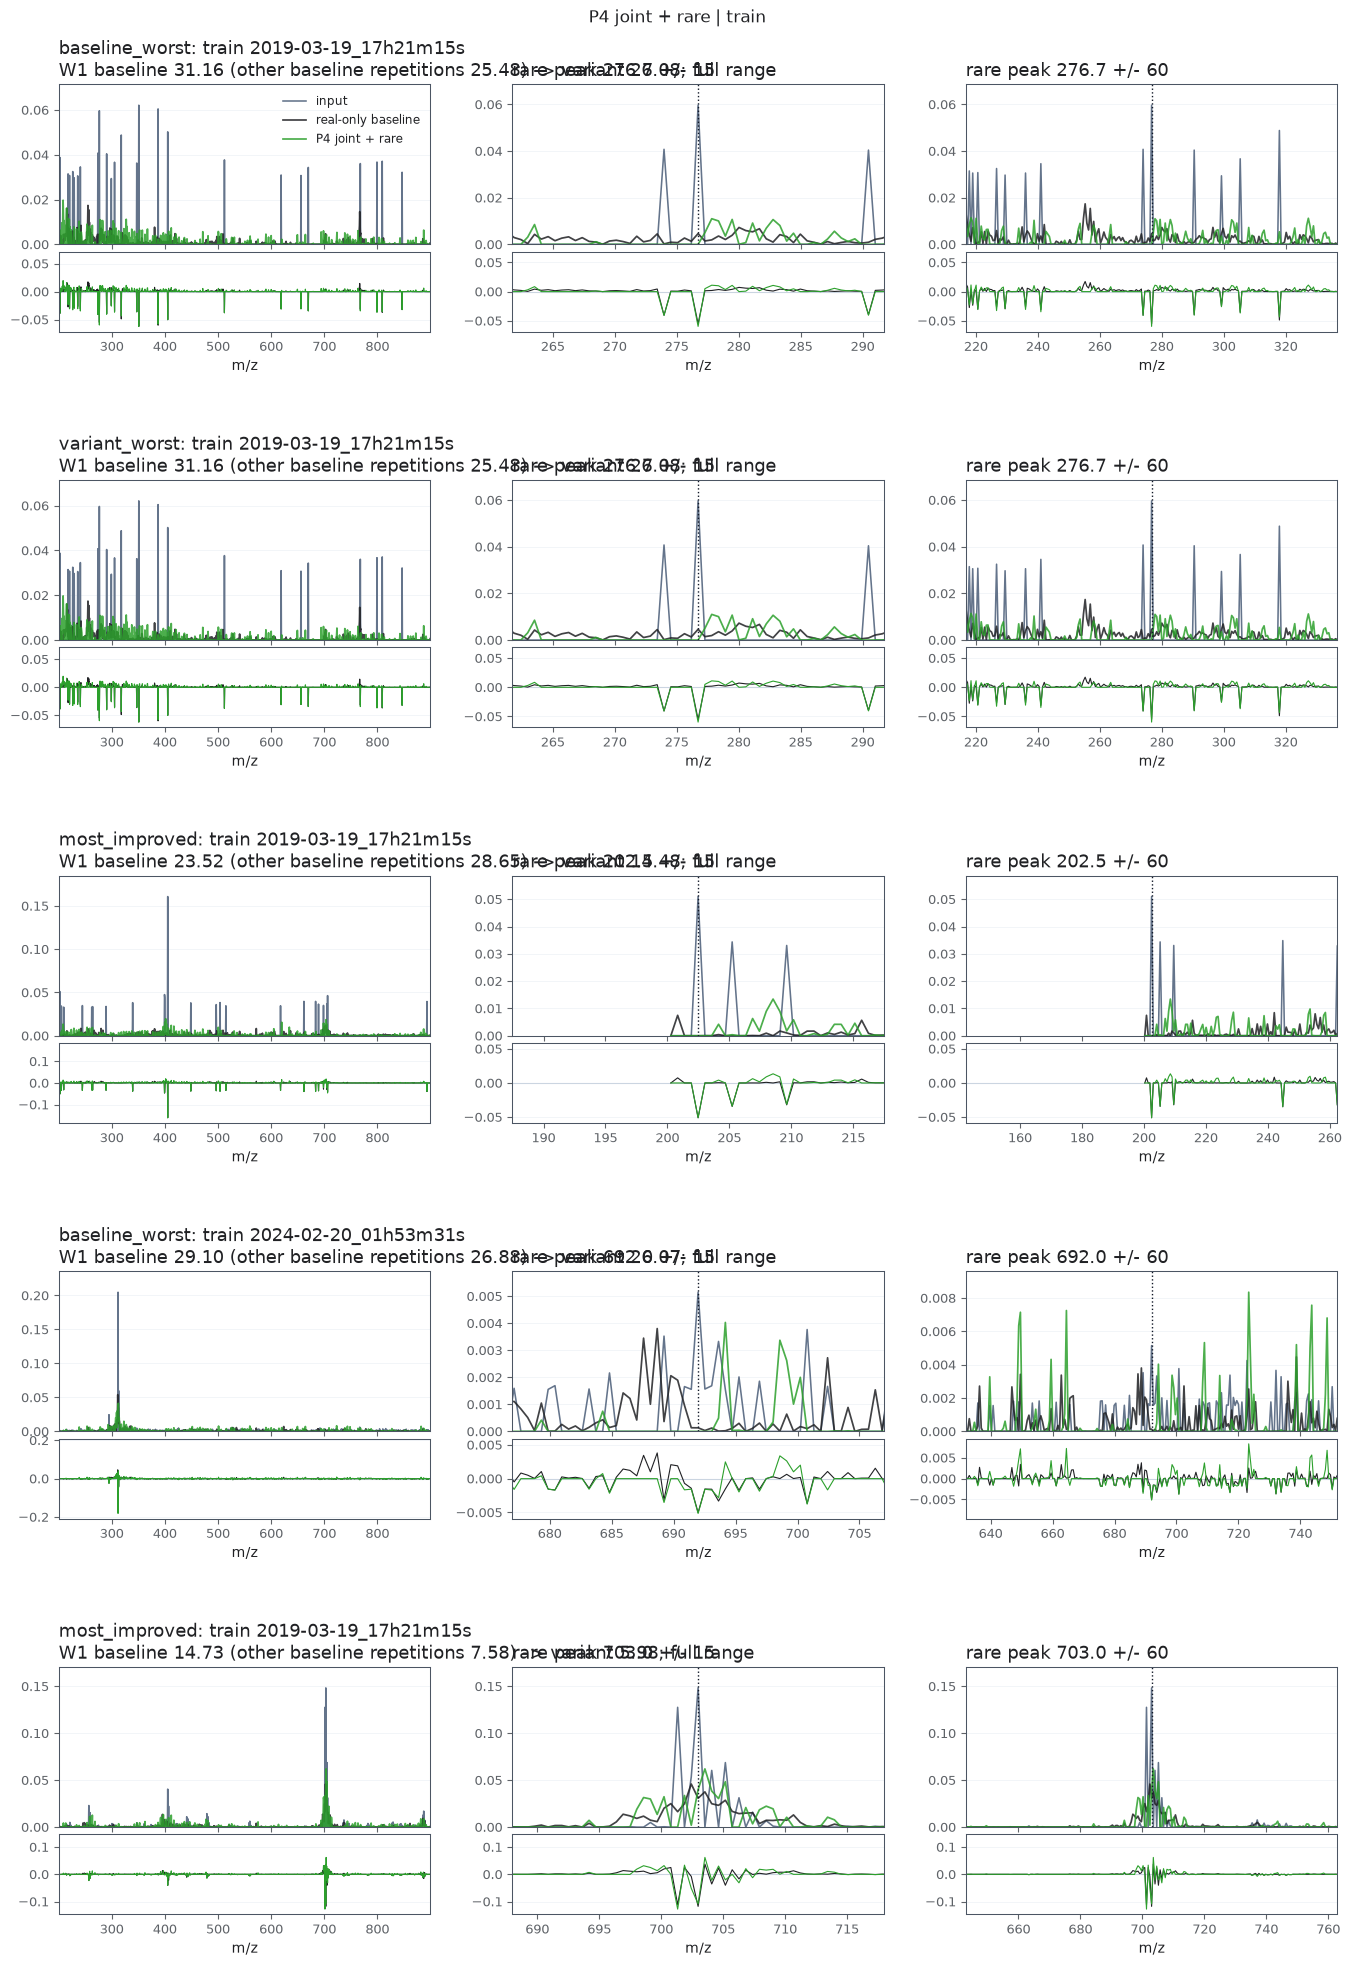

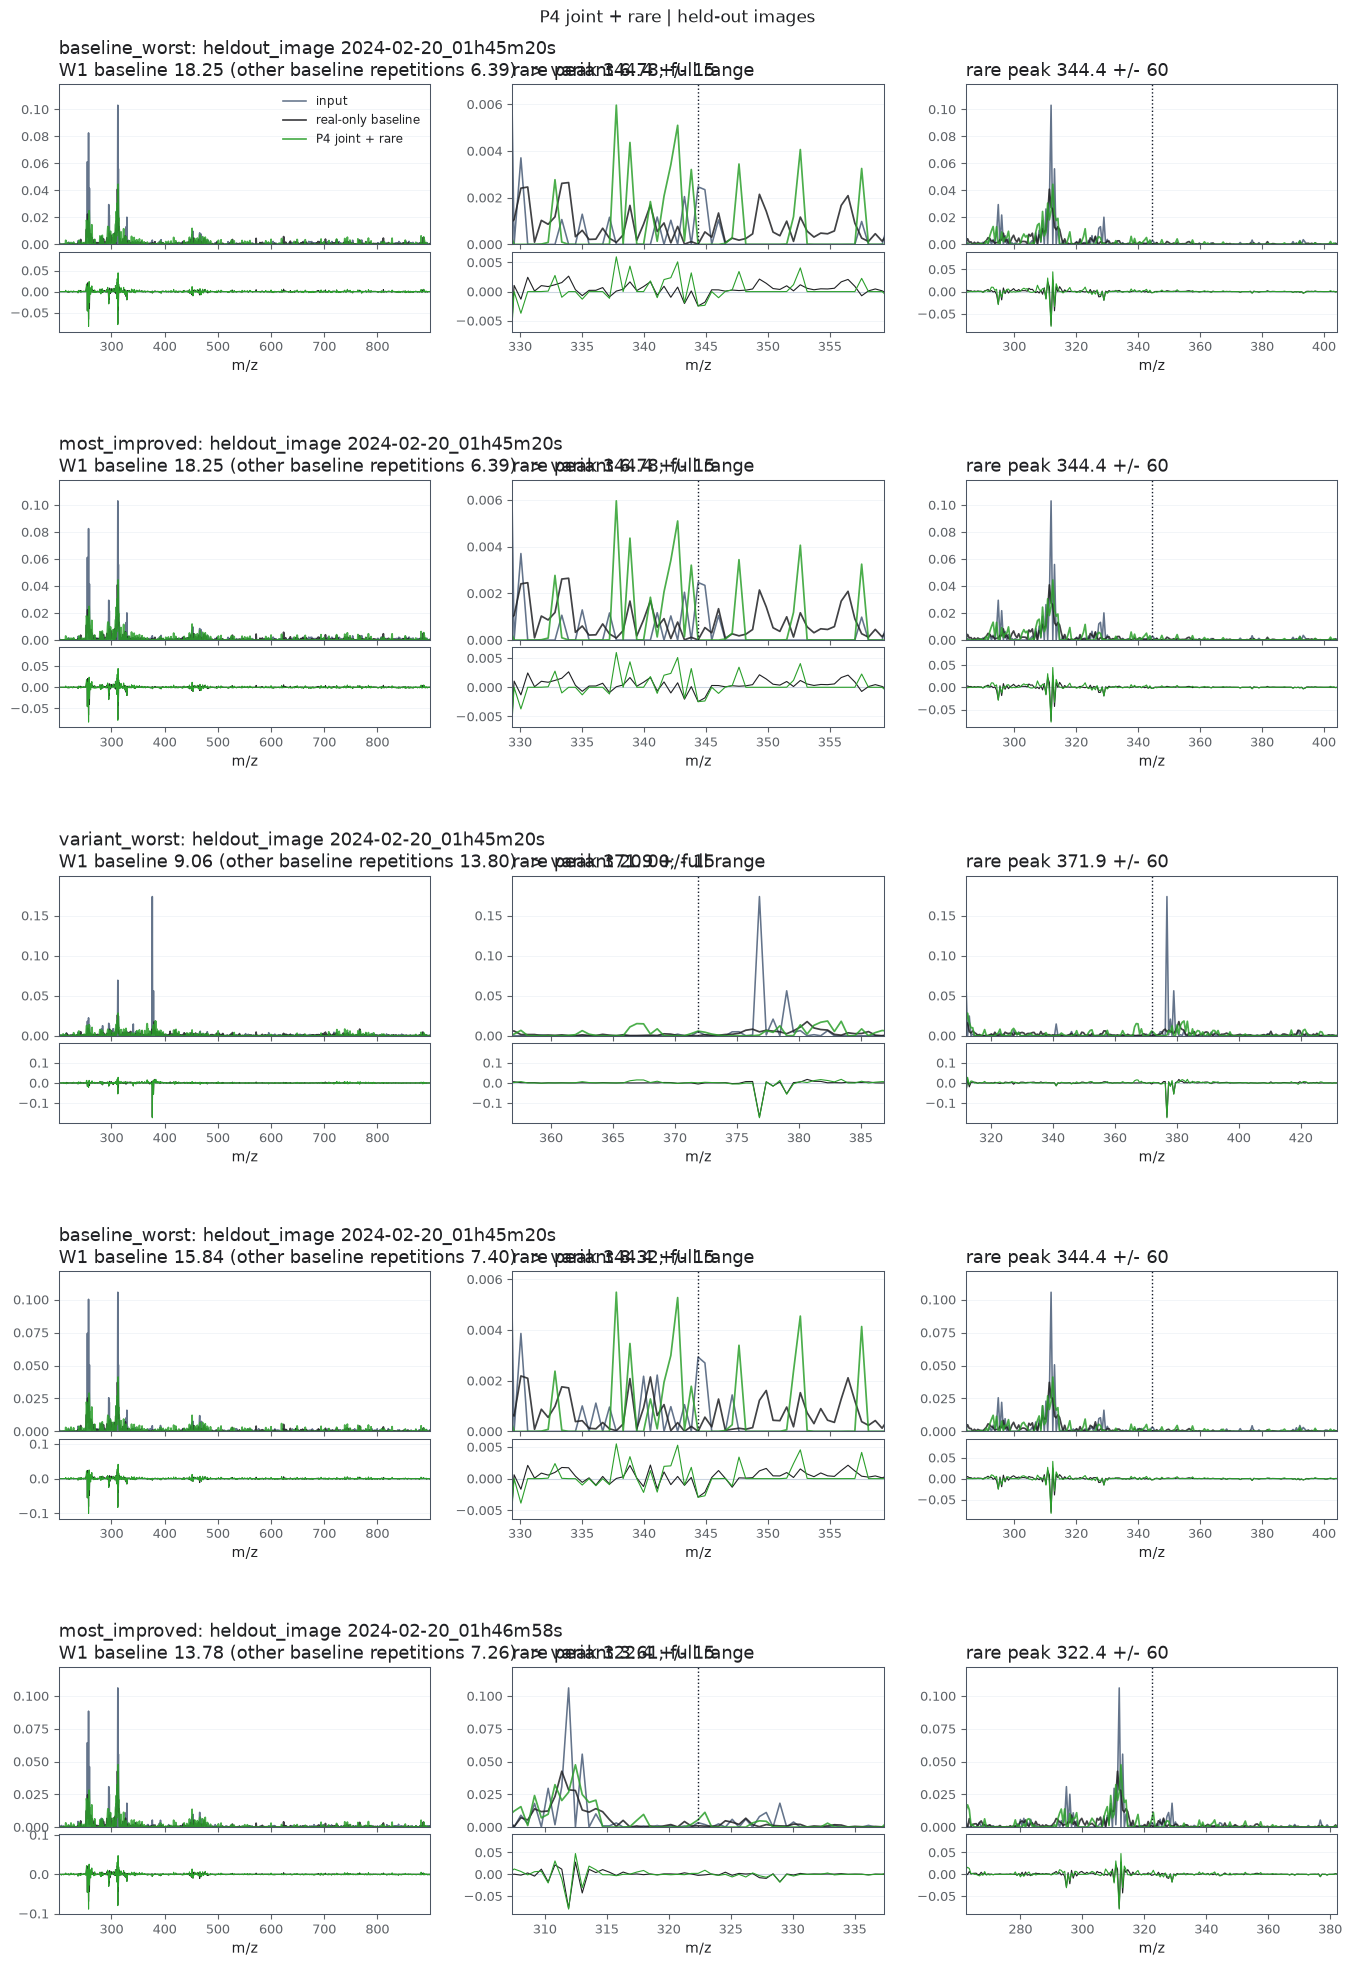

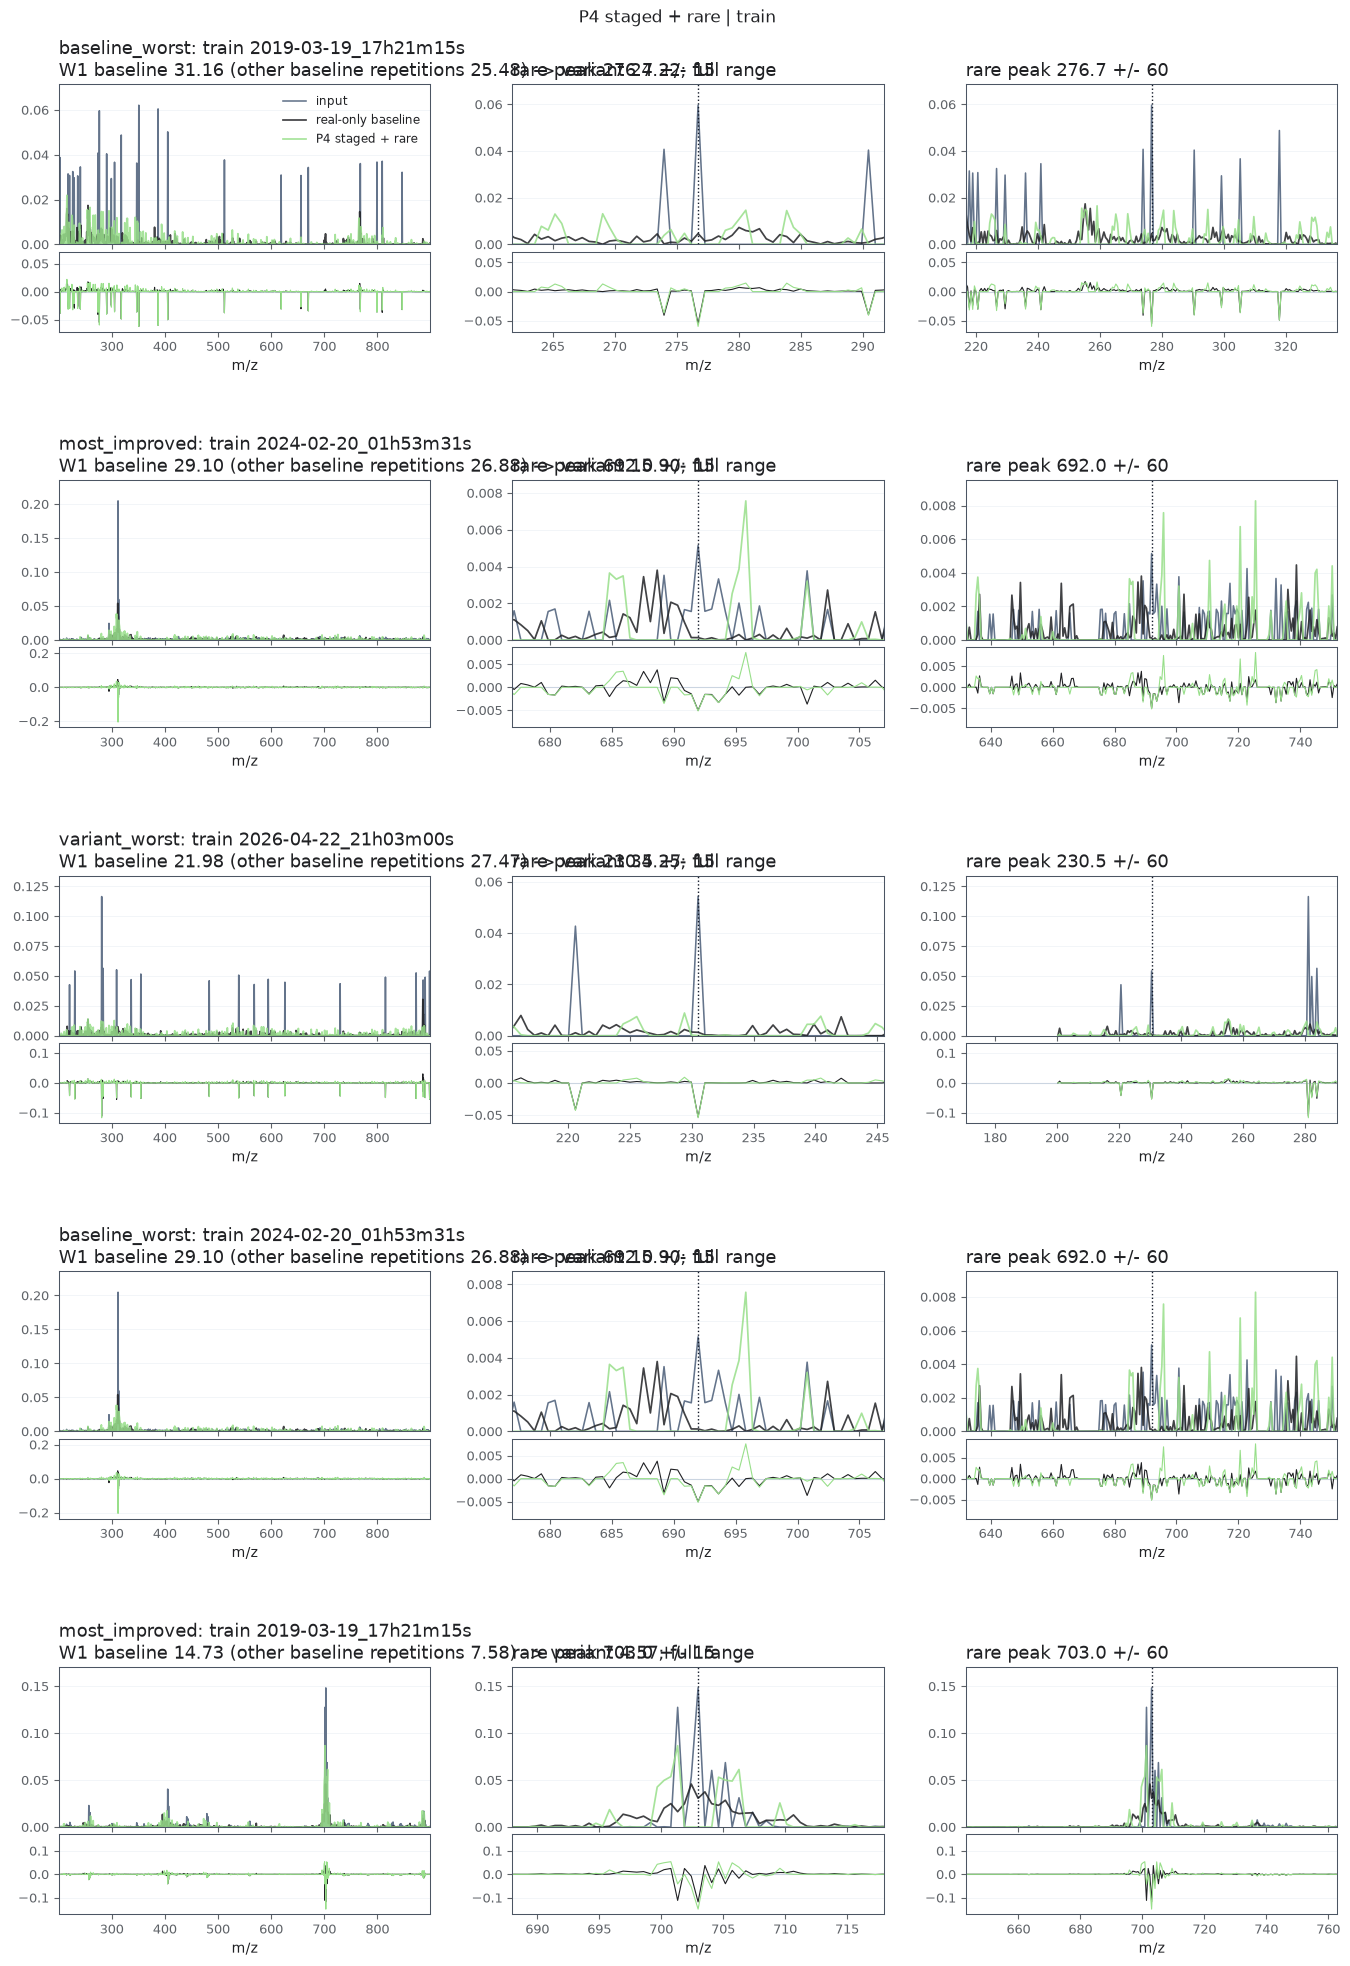

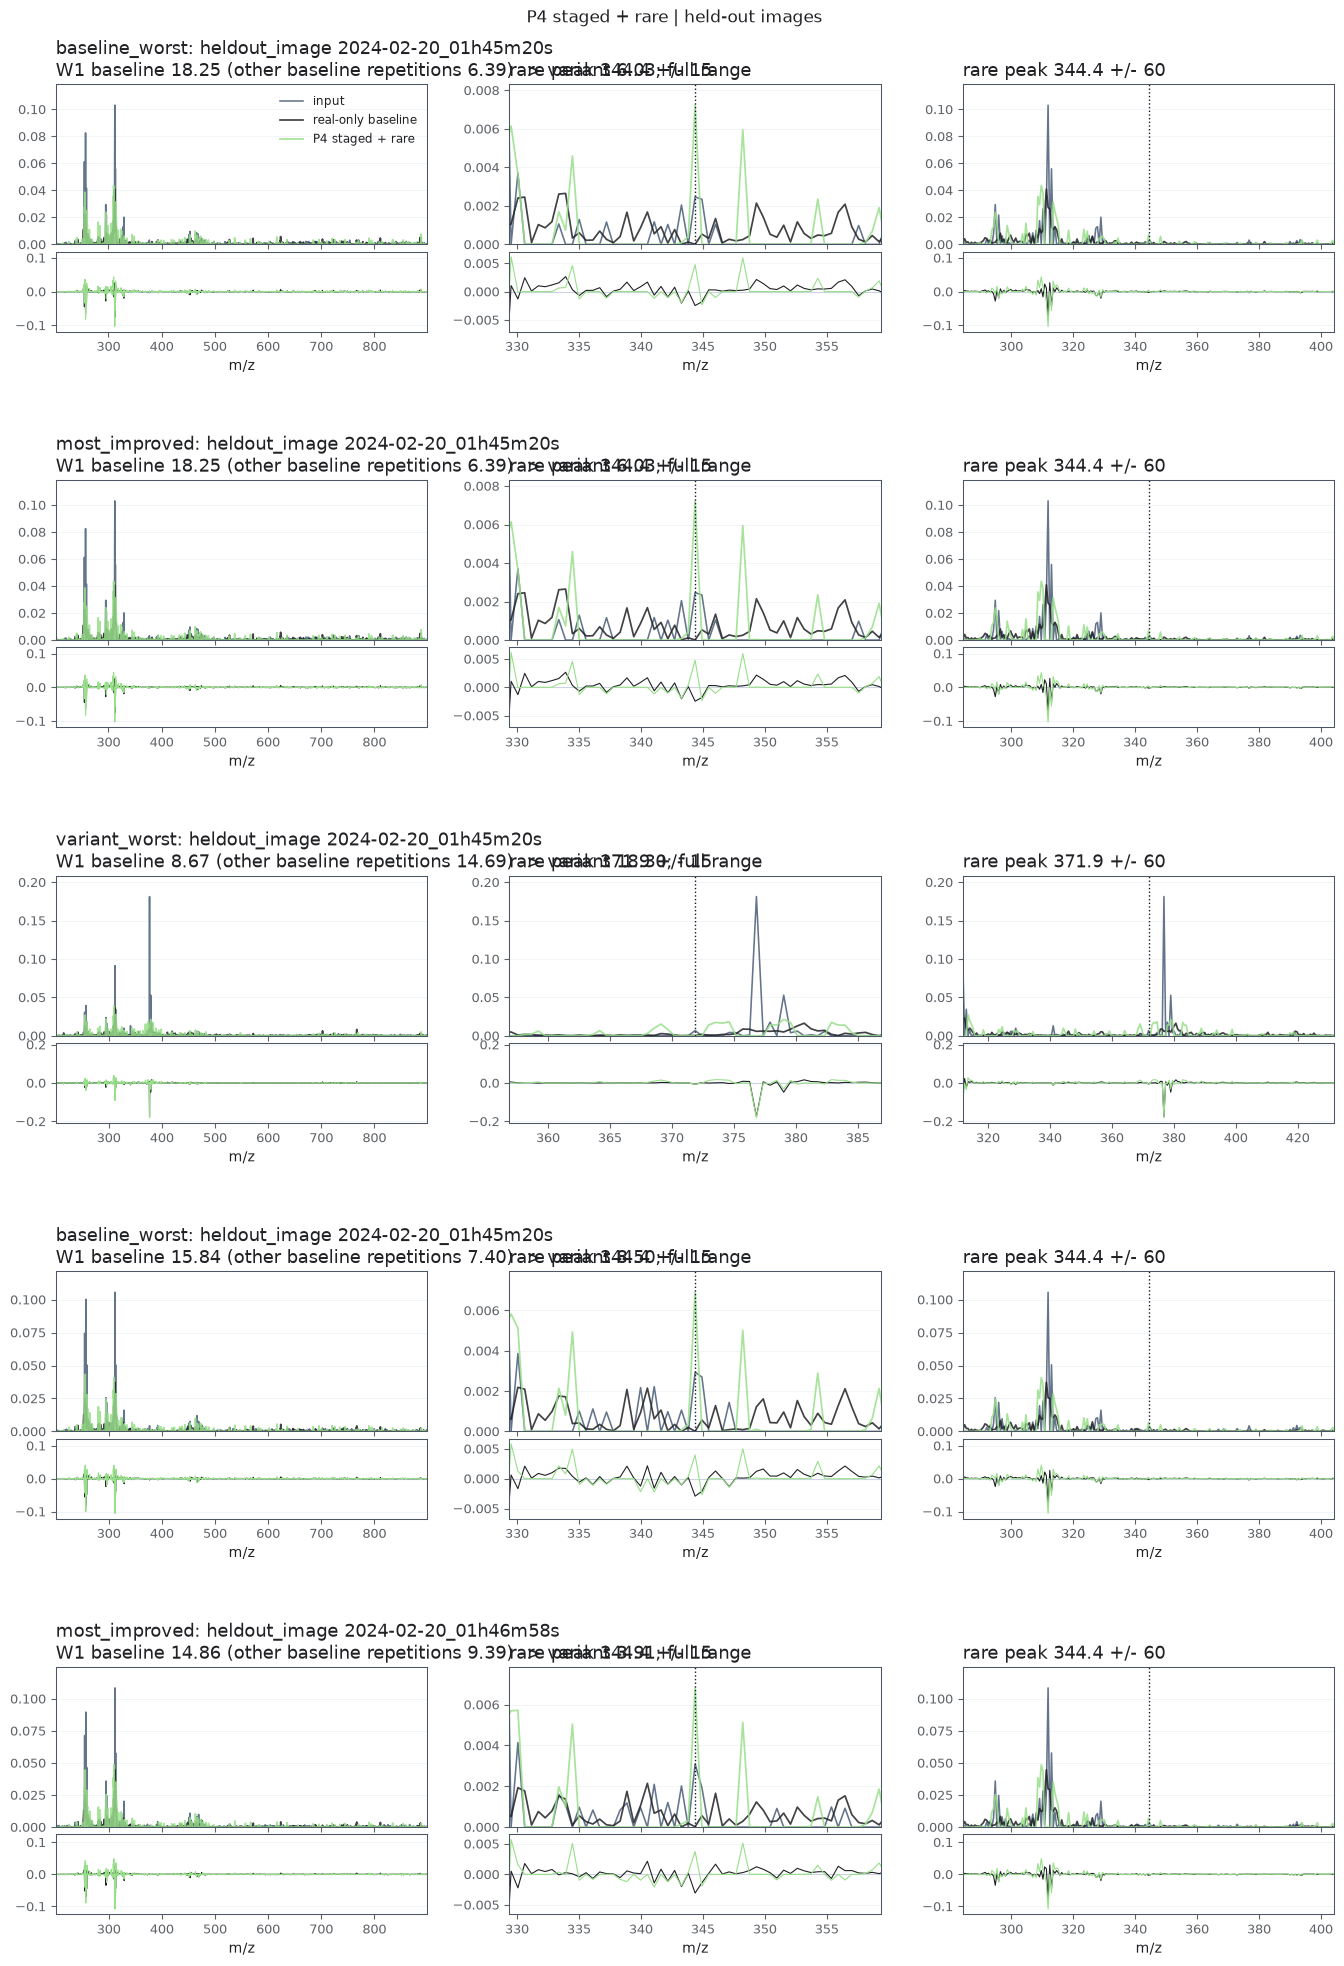

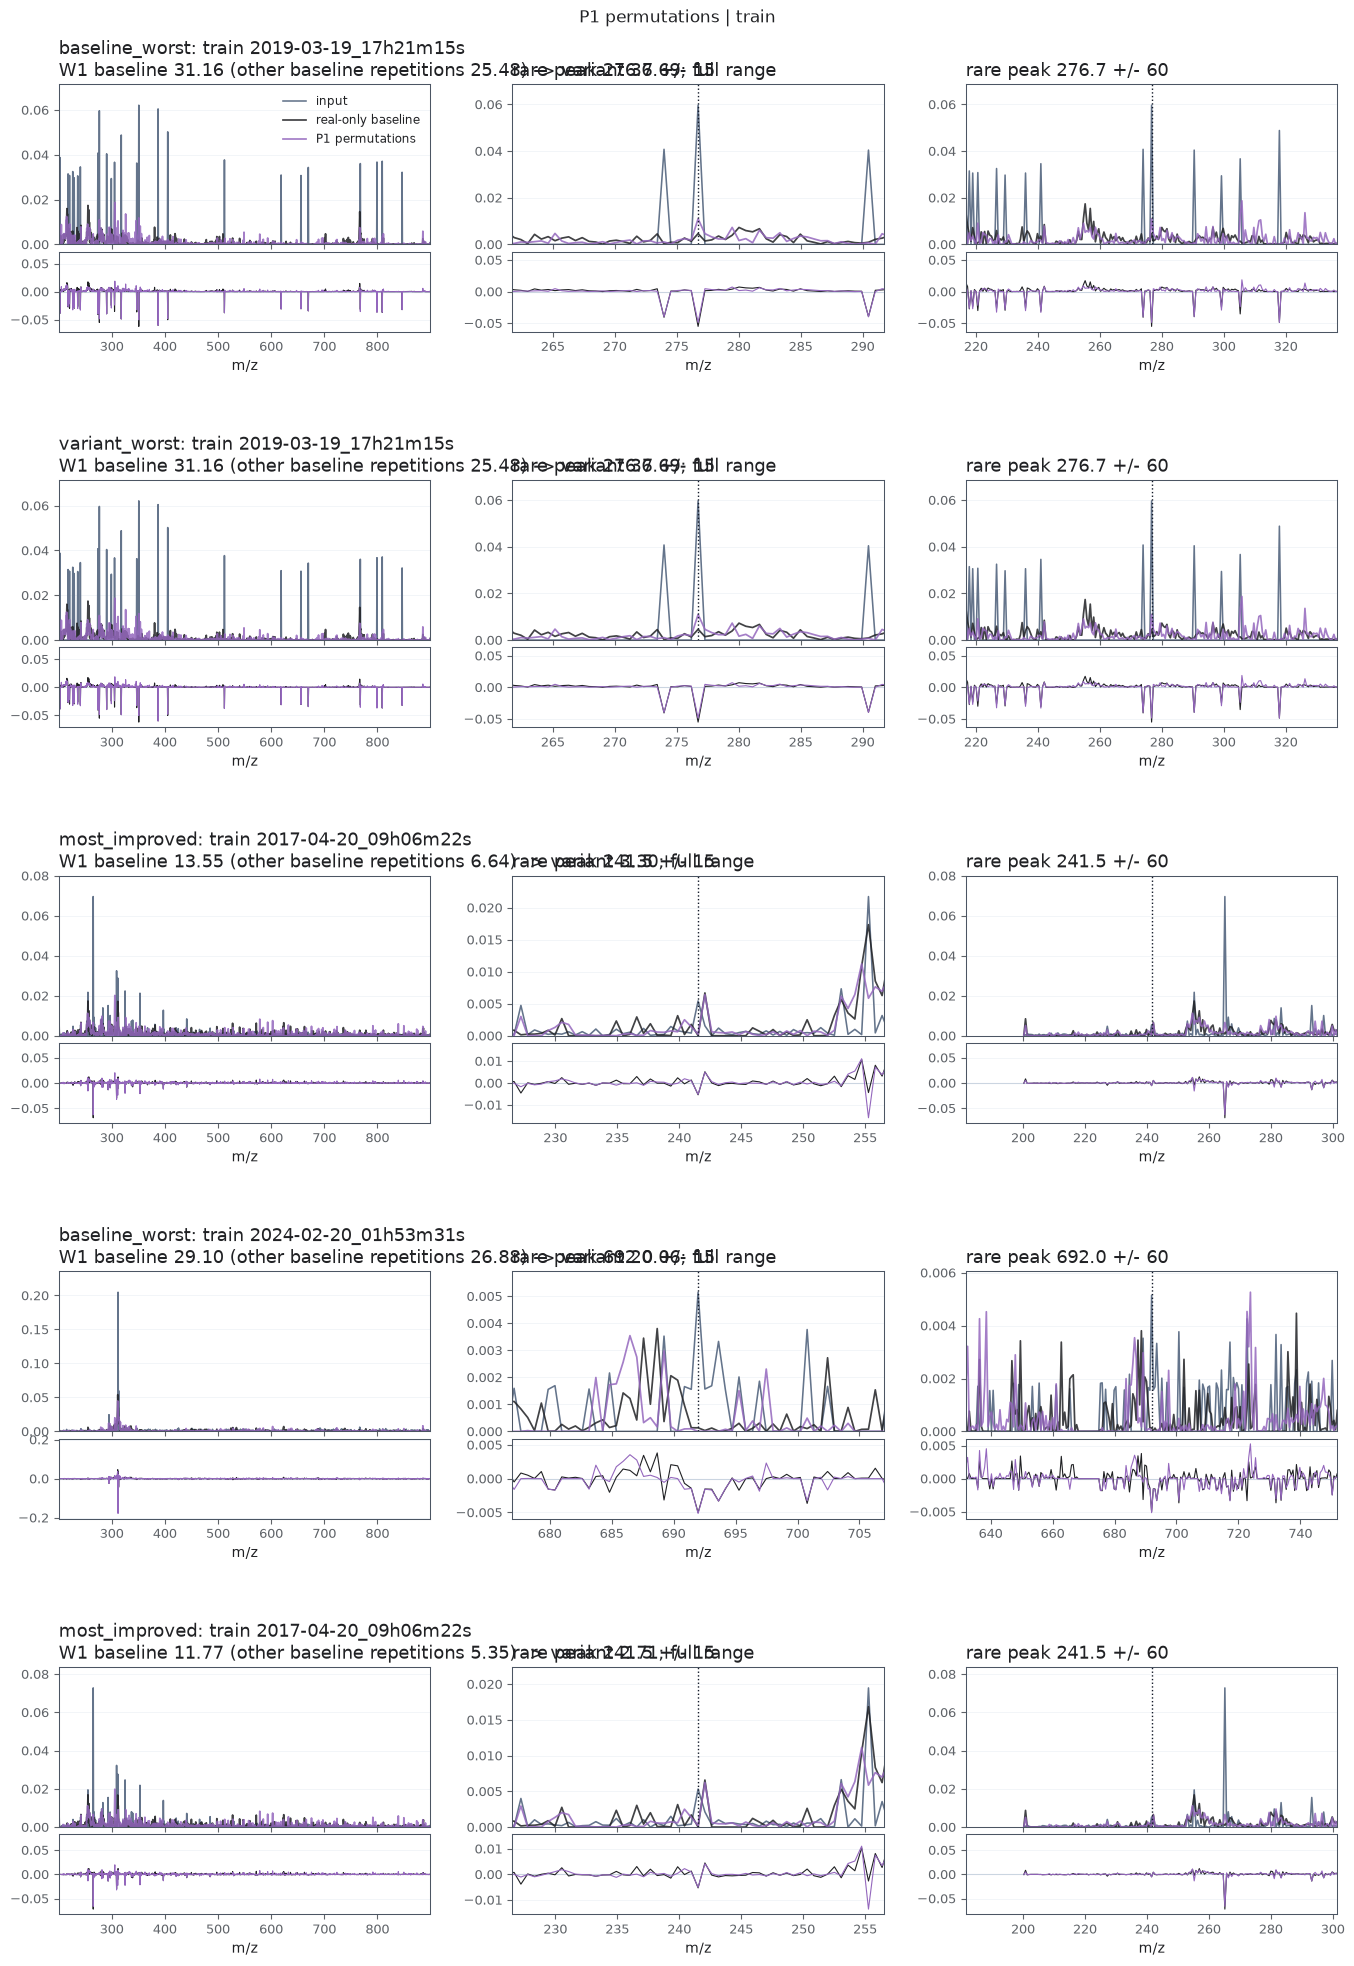

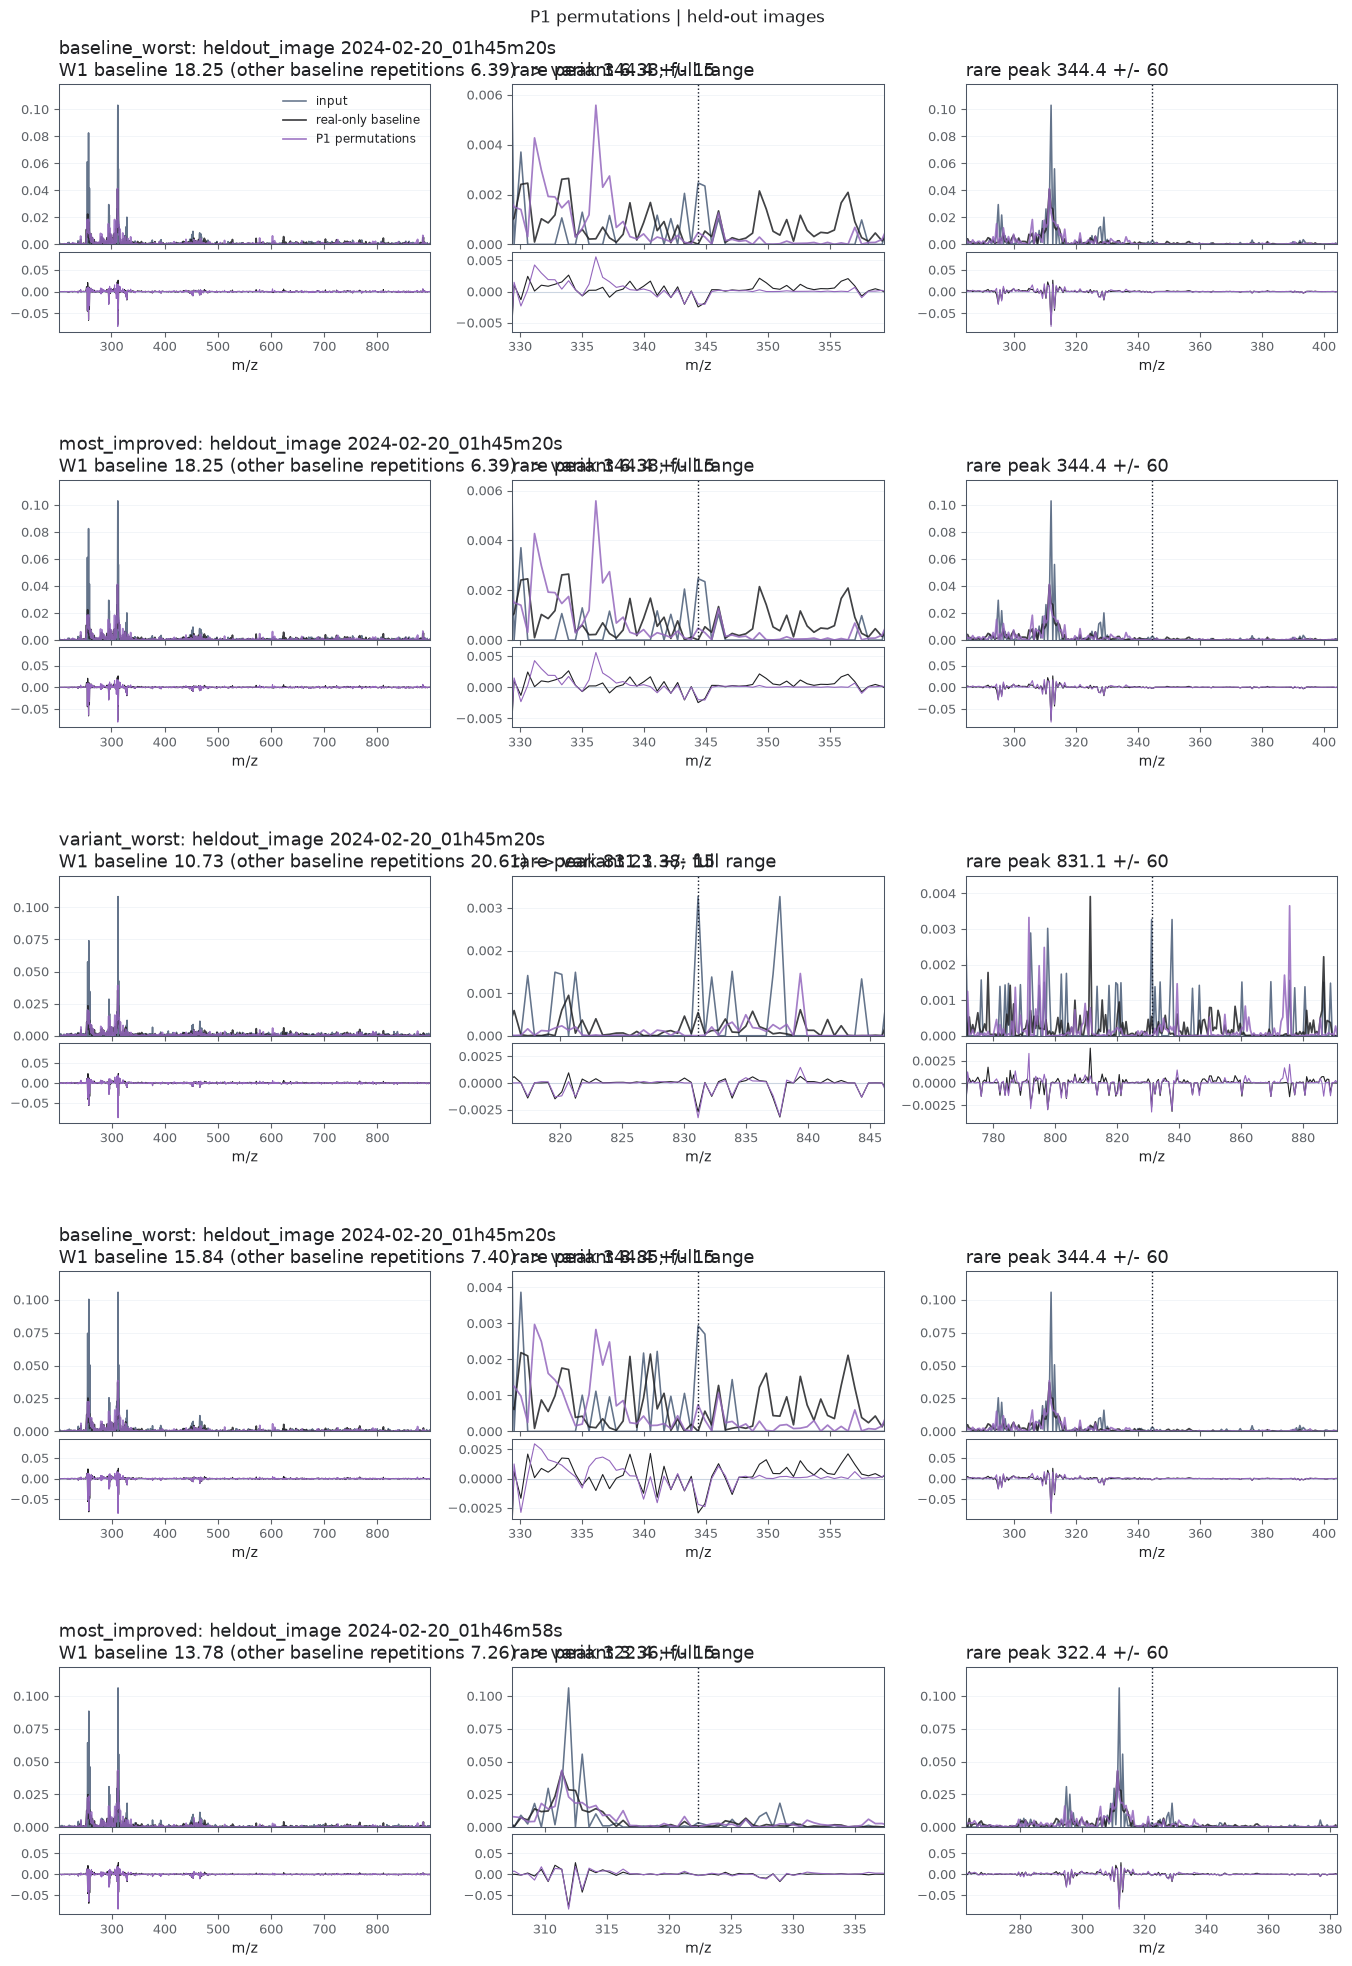

In [14]:
SHOWN_RARE = ['P4_joint_rare', 'P4_staged_rare', 'P1_permutation']
for variant in SHOWN_RARE:
    for population in ('train', 'heldout_image'):
        shown = rare_spectra_table[(rare_spectra_table.variant == variant) & (rare_spectra_table.population == population)].merge(
            rare_pixels[(rare_pixels.variant == variant) & (rare_pixels.population == population)], on=['variant', 'population', 'row'])
        figure = figures.paired_spectra(shown, variant_label=VARIANT_LABELS.get(variant, variant), variant_color=VARIANT_COLORS[variant],
                                        kinds=('baseline_worst', 'most_improved', 'variant_worst'), center='rare_peak_mz', dense=True, theme=theme)
        figure.suptitle(f'{VARIANT_LABELS.get(variant, variant)} | {EVALUATION_NAMES.get(population, population)}', y=1.0)
        plt.show()

### Remarks

- heldout_image: on the two baseline-worst rare-peak pixels (baseline representative W1 17.04, other baseline repetitions 6.90) 10 of 10 fine-tuned variants reduce W1 against the representative, 3 of them also against the other repetitions; P4 joint + rare -9.49; P4 staged + rare -9.78; P1 permutations -9.43.
  largest single improvement: P3 staged + overlap, W1 18.25 -> 5.57 (rare peak 344.4 m/z, present in 4.2 % of the training pixels).
- train: on the two baseline-worst rare-peak pixels (baseline representative W1 30.13, other baseline repetitions 26.18) 10 of 10 fine-tuned variants reduce W1 against the representative, 7 of them also against the other repetitions; P4 joint + rare -4.05; P4 staged + rare -10.07; P1 permutations -1.75.
  largest single improvement: P5 staged + overlap + rare, W1 29.10 -> 15.80 (rare peak 692.0 m/z, present in 0.1 % of the training pixels).

### Notes

## Results / Summary

### LLM

- **Observed:** at the stages that matter (fine-tuned) the rare quota has no detectable effect on its target classes: rare-class macro AP against the matched control is inconclusive for all four pairs at the unfrozen stage; the one positive rare-set cell is P4 joint - P2 joint at the frozen stage (+0.04 AP).
- **Observed:** before real fine-tuning the quota does change the ranking of its targets (median rank of annotated rare classes 29-36 with the quota against 42-50 without), an effect that disappears after unfreezing (77-78 for every variant, baseline 78).
- **Interpretation:** the synthetic head learns the quota, but the retrained head overwrites it. The targets are also not rare in the real data (726-13344 training positives), so the real head already has enough support for them; the quota cannot help the genuinely rare head classes because they are not generator-eligible.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- test_combined | average_precision | rare (by stage, variants pooled): baseline 0.6696; others 0.161-0.6682; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6682), worst pretrained (0.161).
- test_combined | average_precision | rare (unfrozen head, per variant): baseline 0.6696; others 0.6606-0.6757; 4 of 10 better than the baseline; best P0 single bins (0.6757), worst P1 permutations (0.6606).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.6757 vs baseline 0.6696).
- test_extended | average_precision | rare (by stage, variants pooled): baseline 0.7231; others 0.1568-0.7167; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7167), worst pretrained (0.1568).
- test_extended | average_precision | rare (unfrozen head, per variant): baseline 0.7231; others 0.7059-0.7336; 2 of 10 better than the baseline; best P0 single bins (0.7336), worst P5 joint + overlap + rare (0.7059).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.7336 vs baseline 0.7231).
- test_combined | recall | rare (by stage, variants pooled): baseline 0.6383; others 1.563e-06-0.6331; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6331), worst fine-tuned, frozen head (1.563e-06).
- test_combined | recall | rare (unfrozen head, per variant): baseline 0.6383; others 0.5892-0.6622; 4 of 10 better than the baseline; best P5 joint + overlap + rare (0.6622), worst P0 single bins (0.5892).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.6622 vs baseline 0.6383).
- test_extended | recall | rare (by stage, variants pooled): baseline 0.5425; others 0-0.5214; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.5214), worst fine-tuned, frozen head (0).
- test_extended | recall | rare (unfrozen head, per variant): baseline 0.5425; others 0.5094-0.5282; 0 of 10 better than the baseline; best P2 staged (0.5282), worst P2 joint (0.5094).
  best single cell: P2 staged, fine-tuned, unfrozen head (0.5282 vs baseline 0.5425).
- heldout_image | average_precision | other_eligible (by stage, variants pooled): baseline 0.09385; others 0.05492-0.08881; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.08881), worst fine-tuned, frozen head (0.05492).
- heldout_image | average_precision | other_eligible (unfrozen head, per variant): baseline 0.09385; others 0.08393-0.09421; 2 of 10 better than the baseline; best P2 joint (0.09421), worst P4 staged + rare (0.08393).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.09421 vs baseline 0.09385).
- test_combined | average_precision | other_eligible (by stage, variants pooled): baseline 0.912; others 0.3087-0.9152; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9152), worst pretrained (0.3087).
- test_combined | average_precision | other_eligible (unfrozen head, per variant): baseline 0.912; others 0.9082-0.9203; 8 of 10 better than the baseline; best P0 single bins (0.9203), worst P1 permutations (0.9082).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.9203 vs baseline 0.912).
- test_extended | average_precision | other_eligible (by stage, variants pooled): baseline 0.805; others 0.2504-0.7959; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7959), worst pretrained (0.2504).
- test_extended | average_precision | other_eligible (unfrozen head, per variant): baseline 0.805; others 0.7858-0.8084; 1 of 10 better than the baseline; best P0 single bins (0.8084), worst P5 joint + overlap + rare (0.7858).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8084 vs baseline 0.805).
- heldout_image | recall | other_eligible (by stage, variants pooled): baseline 0.003728; others 0-0.004629; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.004629), worst fine-tuned, frozen head (0).
- heldout_image | recall | other_eligible (unfrozen head, per variant): baseline 0.003728; others 0.002212-0.006678; 7 of 10 better than the baseline; best P5 joint + overlap + rare (0.006678), worst P0 single bins (0.002212).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.006678 vs baseline 0.003728).
- test_combined | recall | other_eligible (by stage, variants pooled): baseline 0.9648; others 0-0.9603; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9603), worst fine-tuned, frozen head (0).
- test_combined | recall | other_eligible (unfrozen head, per variant): baseline 0.9648; others 0.9564-0.9644; 0 of 10 better than the baseline; best P1 permutations (0.9644), worst P0 single bins (0.9564).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9644 vs baseline 0.9648).
- test_extended | recall | other_eligible (by stage, variants pooled): baseline 0.7238; others 0-0.7127; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7127), worst fine-tuned, frozen head (0).
- test_extended | recall | other_eligible (unfrozen head, per variant): baseline 0.7238; others 0.6999-0.7259; 1 of 10 better than the baseline; best P5 joint + overlap + rare (0.7259), worst P0 single bins (0.6999).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.7259 vs baseline 0.7238).
- heldout_image: on the two baseline-worst rare-peak pixels (baseline representative W1 17.04, other baseline repetitions 6.90) 10 of 10 fine-tuned variants reduce W1 against the representative, 3 of them also against the other repetitions; P4 joint + rare -9.49; P4 staged + rare -9.78; P1 permutations -9.43.
  largest single improvement: P3 staged + overlap, W1 18.25 -> 5.57 (rare peak 344.4 m/z, present in 4.2 % of the training pixels).
- train: on the two baseline-worst rare-peak pixels (baseline representative W1 30.13, other baseline repetitions 26.18) 10 of 10 fine-tuned variants reduce W1 against the representative, 7 of them also against the other repetitions; P4 joint + rare -4.05; P4 staged + rare -10.07; P1 permutations -1.75.
  largest single improvement: P5 staged + overlap + rare, W1 29.10 -> 15.80 (rare peak 692.0 m/z, present in 0.1 % of the training pixels).

### Person